In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

- 공공데이터 포털에 있는 데이터를 Pandas의 melt, concat, transpose와 같은 reshape 기능을 활용해 분석
- groupby, pivot_table, info, describe, value_counts등을 통한 데이터 요약과 분석
- 이를 통해 전혀 다른 두 데이터의 정제와 병합, 수치형 데이터의 차이를 이해하고 다양한 그래프로 시각화(barplot, lineplot, scatterplot, lmplot, swarmplot, histplot)

# 1. 패키지로드 & 한글설정 & 경고메세지 ignore

In [193]:
# 패키지 import
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 시각화의 선명도를 높임
%config InlineBackend.figure_format = "retina"

# 한글설정
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

# 다른 폰트를 기본으로 하려면
import matplotlib.font_manager as fm
font_file = 'C:/Windows/Fonts/HMKMAMI.TTF'
font_name = fm.FontProperties(fname=font_file,
                             #size=10
                             ).get_name()
plt.rc('font',family=font_name)

# warning(경고) 안보이게
import warnings
#warnings.filterwarnings(action='default')
warnings.filterwarnings(action='ignore') #경고 메세지 무시

# 2. 데이터 다운로드
- https://www.data.go.kr 에서 "아파트 분양 가격"을 검색한 csv 다운로드

## (1) 2013년9월부터 2015년8월까지 데이터는 df_first 변수에 담아 탐색

In [194]:
%ls "C:/ai_x/download/shareData/부동산"

 C 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: 3664-591E

 C:\ai_x\download\shareData\부동산 디렉터리

2025-04-30  오후 02:50    <DIR>          .
2025-04-30  오후 02:50    <DIR>          ..
2025-04-30  오후 02:50             2,163 전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv
2025-04-30  오후 02:49           419,340 주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20241231.csv
               2개 파일             421,503 바이트
               2개 디렉터리  160,414,777,344 바이트 남음


In [195]:
df_first = pd.read_csv('C:/ai_x/download/shareData/부동산/전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv', encoding='cp949')
df_first.head()

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,19404,19759,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443
1,부산,8111,8111,9078,8965,9402,9501,9453,9457,9411,9258,9110,9208,9208,9204,9235,9279,9327,9345,9515,9559,9581
2,대구,8080,8080,8077,8101,8267,8274,8360,8360,8370,8449,8403,8439,8253,8327,8416,8441,8446,8568,8542,8542,8795
3,인천,10204,10204,10408,10408,10000,9844,10058,9974,9973,9973,10016,10020,10020,10017,9876,9876,9938,10551,10443,10443,10449
4,광주,6098,7326,7611,7346,7346,7523,7659,7612,7622,7802,7707,7752,7748,7752,7756,7861,7914,7877,7881,8089,8231


In [196]:
df_first.shape #17행 22열

(17, 22)

In [197]:
pd.options.display.max_columns = 22
df_first.tail(1)

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
16,제주,7674,7900,7900,7900,7900,7900,7914,7914,7914,7833,7724,7724,7739,7739,7739,7826,7285,7285,7343,7343,7343


In [198]:
df_first.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   지역        17 non-null     object
 1   2013년12월  17 non-null     int64 
 2   2014년1월   17 non-null     int64 
 3   2014년2월   17 non-null     int64 
 4   2014년3월   17 non-null     int64 
 5   2014년4월   17 non-null     int64 
 6   2014년5월   17 non-null     int64 
 7   2014년6월   17 non-null     int64 
 8   2014년7월   17 non-null     int64 
 9   2014년8월   17 non-null     int64 
 10  2014년9월   17 non-null     int64 
 11  2014년10월  17 non-null     int64 
 12  2014년11월  17 non-null     int64 
 13  2014년12월  17 non-null     int64 
 14  2015년1월   17 non-null     int64 
 15  2015년2월   17 non-null     int64 
 16  2015년3월   17 non-null     int64 
 17  2015년4월   17 non-null     int64 
 18  2015년5월   17 non-null     int64 
 19  2015년6월   17 non-null     int64 
 20  2015년7월   17 non-null     int64 
 21  2015년8월   17 non-n

In [199]:
# isna(), isnull() - 결측치 여부
# notnull(), notna() - 결측치가 아닌지 여부
df_first.isna().sum()

지역          0
2013년12월    0
2014년1월     0
2014년2월     0
2014년3월     0
2014년4월     0
2014년5월     0
2014년6월     0
2014년7월     0
2014년8월     0
2014년9월     0
2014년10월    0
2014년11월    0
2014년12월    0
2015년1월     0
2015년2월     0
2015년3월     0
2015년4월     0
2015년5월     0
2015년6월     0
2015년7월     0
2015년8월     0
dtype: int64

In [200]:
# set_index('열이름') : 열을 index로 settting
# reset_index() : index를 열로 setting
df_first.set_index('지역', inplace=True)

- color map 참조 : https://matplotlib.org/stable/users/explain/colors/colormaps.html

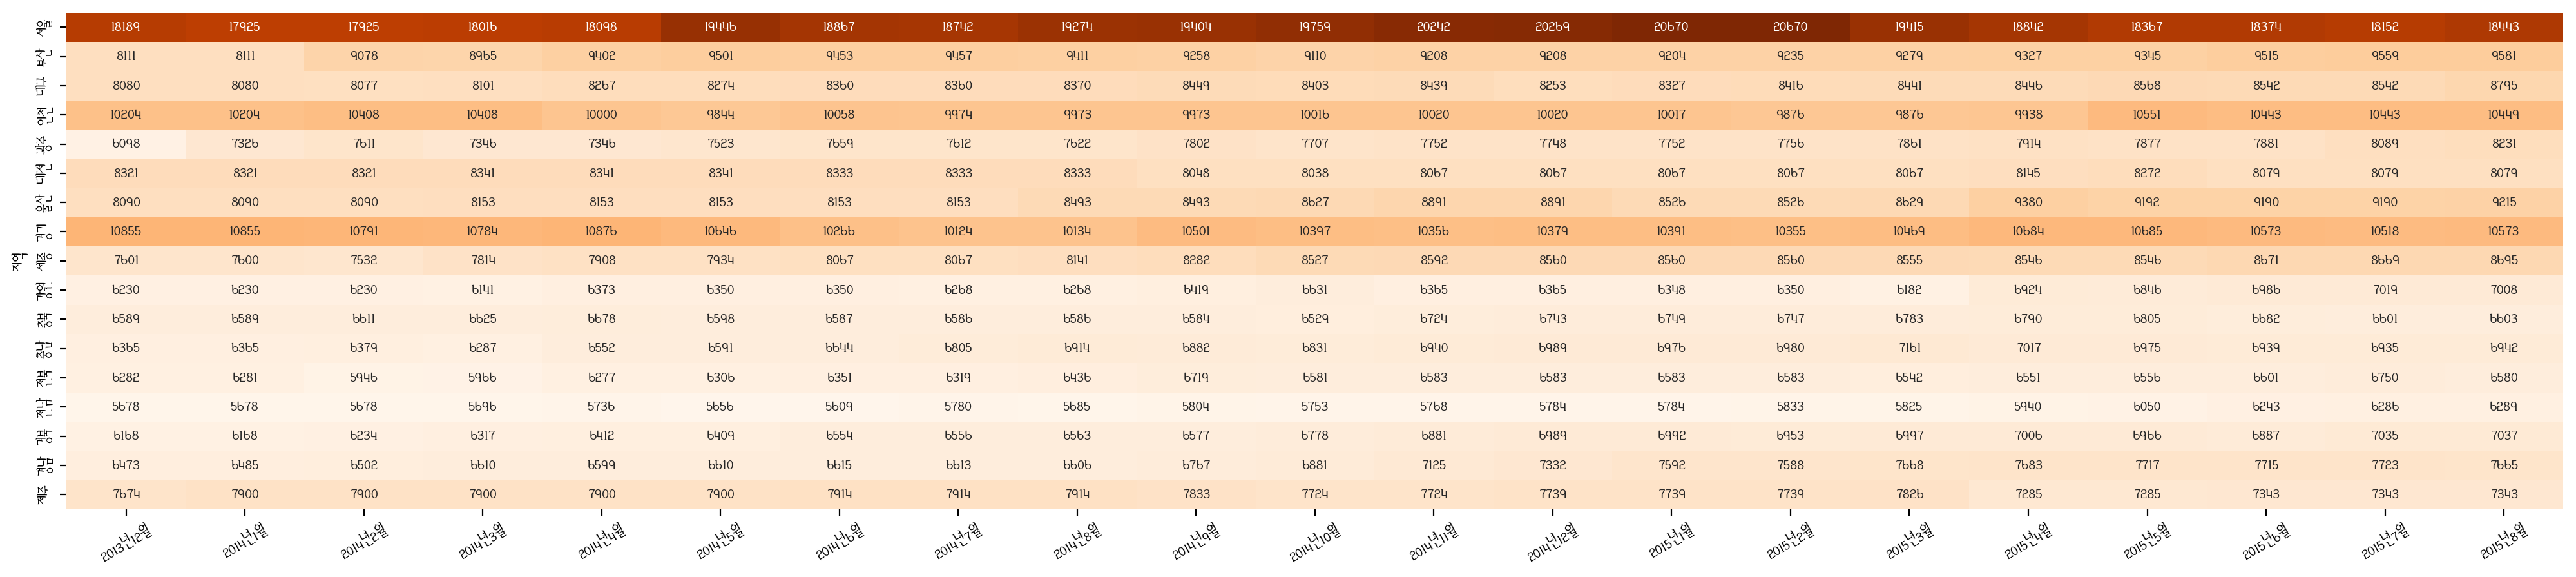

In [201]:
df_first.head()
plt.figure(figsize=(25,5))
sns.heatmap(df_first, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.xticks(rotation=30)
plt.show()

## (2) 2015이후 데이터 분양가격에 간헐적으로 comma(,) 추가하여 csv로 출력
- 분양가격에 np.nan, ' ', '   ', 8111->np.nan, ' ', '   ', '8,111'

In [202]:
ex=pd.read_csv('C:/ai_x/download/shareData/부동산/주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20241231.csv', encoding='cp949')
ex.head()

,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,5841
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879


In [203]:
ex.isna().sum()

지역명             0
규모구분            0
연도              0
월               0
분양가격(제곱미터)    614
dtype: int64

In [204]:
# isna(), isnull() - 결측치 여부
# notnull(), notna() - 결측치가 아닌지 여부
print('전체 갯수:', ex.shape[0])
print('결측치 아닌 갯수', ex['분양가격(제곱미터)'].notna().sum())
print('결측치 갯수', ex['분양가격(제곱미터)'].isna().sum())

전체 갯수: 9095
결측치 아닌 갯수 8481
결측치 갯수 614


In [205]:
# 분양가격(제곱미터)가 결측치인 행 상위2개
ex[ex['분양가격(제곱미터)'].isnull()].head(2)

,지역명,규모구분,연도,월,분양가격(제곱미터)
368,광주,전용면적 85제곱미터초과 102제곱미터이하,2016,2,NaN
369,광주,전용면적 102제곱미터초과,2016,2,NaN


In [206]:
type(ex.loc[368, '분양가격(제곱미터)']), type(ex.loc[0,'분양가격(제곱미터)'])

(float, str)

In [207]:
# 분양가격(제곱미터) 컬럼의 type을 float64로 타입 변환 : astype(), pd.to_numeric()
# ex['분양가격(제곱미터)'].astype('float64')#에러 이유:'  '
# pd.to_numeric(ex['분양가격(제곱미터)'], errors='coerce') # 에러나는 행은 NaN으로 
pd.to_numeric(ex['분양가격(제곱미터)'], errors='coerce').isna().sum()

740

In [208]:
# 분양가격(제곱미터) 컬럼이 space인 행 :740-614=126개
ex[ex['분양가격(제곱미터)'].str.strip()==''].head(1)

,지역명,규모구분,연도,월,분양가격(제곱미터)
28,광주,전용면적 85제곱미터초과 102제곱미터이하,2015,10,


In [209]:
nanex=ex.loc[368]
spaceex=ex.loc[28]
ex.loc[0] #분양가격이 정상인 데이터

지역명             서울
규모구분          모든면적
연도            2015
월               10
분양가격(제곱미터)    5841
Name: 0, dtype: object

In [210]:
# 분양가격이 nan이거나 space면 0, 그외 분양가격의 문자자리수를 return하는 함수
def get_pricelen(row):
    price = row['분양가격(제곱미터)']
    #np.isnan(스칼라변수) : 스칼라변수가 결측치(np.nan)인지 여부
    #pd.isna(스칼라변수) : 스칼라변수가 결측치(np.nan, Nane)인지 여부
    #pd.notnull(스칼라변수) : 결측치가 아닌지 여부
    #1차원이나 2차원변수.isna() : 결측치 여부
    if pd.notnull(price) and price.strip()!='':
        return len(price)
    else:
        return 0

get_pricelen(nanex), get_pricelen(spaceex), get_pricelen(ex.loc[0])

(0, 0, 4)

In [211]:
#자리수열 추가
ex['자리수'] = ex.apply(get_pricelen, axis=1)
ex.head(2)

,지역명,규모구분,연도,월,분양가격(제곱미터),자리수
0,서울,모든면적,2015,10,5841,4
1,서울,전용면적 60제곱미터이하,2015,10,5652,4


In [212]:
ex.자리수.unique()

array([4, 0, 5], dtype=int64)

In [213]:
#index이름 idx로
ex.index.name = 'idx'
ex.head()

,지역명,규모구분,연도,월,분양가격(제곱미터),자리수
idx,,,,,,
0,서울,모든면적,2015,10,5841,4
1,서울,전용면적 60제곱미터이하,2015,10,5652,4
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882,4
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721,4
4,서울,전용면적 102제곱미터초과,2015,10,5879,4


In [214]:
#index를 열로
ex = ex.reset_index()
ex.head()

,idx,지역명,규모구분,연도,월,분양가격(제곱미터),자리수
0,0,서울,모든면적,2015,10,5841,4
1,1,서울,전용면적 60제곱미터이하,2015,10,5652,4
2,2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882,4
3,3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721,4
4,4,서울,전용면적 102제곱미터초과,2015,10,5879,4


In [215]:
#자리수가 5이면서 idx가 5의 배수인 행 : 9010번째
ex[(ex.자리수 == 5)&(ex.idx%5 == 0)]

,idx,지역명,규모구분,연도,월,분양가격(제곱미터),자리수
8245,8245,서울,모든면적,2023,11,10347,5
8330,8330,서울,모든면적,2023,12,10590,5
8415,8415,서울,모든면적,2024,1,11234,5
8500,8500,서울,모든면적,2024,2,11457,5
8585,8585,서울,모든면적,2024,3,11498,5
8670,8670,서울,모든면적,2024,4,11770,5
8755,8755,서울,모든면적,2024,5,11706,5
8845,8845,인천,모든면적,2024,6,12676,5
8925,8925,서울,모든면적,2024,7,13315,5
9010,9010,서울,모든면적,2024,8,13043,5


In [216]:
#컴마추가x : nanex, spaceex, ex.loc[1]
#컴마추가 : ex.loc[0], ex.loc[8245]

In [217]:
nanex=ex.loc[368]
spaceex=ex.loc[28]
ex.loc[0] #분양가격이 정상인 데이터

idx              0
지역명             서울
규모구분          모든면적
연도            2015
월               10
분양가격(제곱미터)    5841
자리수              4
Name: 0, dtype: object

In [218]:
# 2022년 데이터 흉내내기 위한 함수  : 매개변수로 row를 받아 nan, ' ', '  ', '5123', '5,123' return
def comma_append(row):
    price = row['분양가격(제곱미터)']
    if (row.idx%5==0)&(row.자리수>=4):
        price = price[:-3] + ',' + price[-3:]
    return price

comma_append(nanex), comma_append(spaceex), comma_append(ex.loc[1]),\
comma_append(ex.loc[0]), comma_append(ex.loc[8245])

(nan, '  ', '5652', '5,841', '10,347')

In [219]:
#컴마 추가-1번만 실행
ex['분양가격(제곱미터)'] = ex.apply(comma_append, axis=1)
ex.head()

,idx,지역명,규모구분,연도,월,분양가격(제곱미터),자리수
0,0,서울,모든면적,2015,10,"5,841",4
1,1,서울,전용면적 60제곱미터이하,2015,10,5652,4
2,2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882,4
3,3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721,4
4,4,서울,전용면적 102제곱미터초과,2015,10,5879,4


In [220]:
ex.drop(['idx', '자리수'], axis=1, inplace=True)

In [221]:
ex

,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,"5,841"
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879
...,...,...,...,...,...
9090,제주,모든면적,2024,8,"7,703"
9091,제주,전용면적 60제곱미터이하,2024,8,NaN
9092,제주,전용면적 60제곱미터초과 85제곱미터이하,2024,8,7515
9093,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,8,NaN


In [222]:
# 간헐적으로 평당분양가에 ,가 있거나 np.nan이 있거나 space가 있는 데이터 csv로 백업
ex.to_csv('C:/ai_x/download/shareData/부동산전국제곱미터당분양가격(2015년10월부터).csv',
           # encoding = 'cp949',
           # sep='\t',
           index=False)

## (3) 이후 데이터는 df_last 변수에 담아 탐색

In [223]:
df_last = pd.read_csv('C:/ai_x/download/shareData/부동산전국제곱미터당분양가격(2015년10월부터).csv')
display(df_last.head(1))
print(df_last.shape)

,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,"5,841"


(9095, 5)


In [224]:
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9095 entries, 0 to 9094
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   지역명         9095 non-null   object
 1   규모구분        9095 non-null   object
 2   연도          9095 non-null   int64 
 3   월           9095 non-null   int64 
 4   분양가격(제곱미터)  8481 non-null   object
dtypes: int64(2), object(3)
memory usage: 355.4+ KB


In [225]:
# 데이터 요약하기


# 3. df_last의 데이터 결측치를 확인하고 대체 고민

In [226]:
# 열별 결측치 갯수
df_last.isna().sum()

지역명             0
규모구분            0
연도              0
월               0
분양가격(제곱미터)    614
dtype: int64

In [227]:
# 열별 결측치를 제외한 갯수
df_last.notna().sum()

지역명           9095
규모구분          9095
연도            9095
월             9095
분양가격(제곱미터)    8481
dtype: int64

# 4. df_last 데이셋에 평당분양가격컬럼 추가

## (1) astype('float')나 pd.to_numeric() 사용
## (2) 6,222 => 6222 수정, space가 저장된 경우 nan으로 수정하는 함수를 apply나 map적용
## (3) df_last['분양가격(제곱미터)']*3.3

In [228]:
#df_last['분양가격(제곱미터)'].astype('float64')*3.3
#df_last['분양가격(제곱미터)'].str.replace(',','').astype('float64')*3.3
#,와 space때문에 에러
pd.to_numeric(df_last['분양가격(제곱미터)'], errors='coerce') # 비추

0          NaN
1       5652.0
2       5882.0
3       5721.0
4       5879.0
         ...  
9090       NaN
9091       NaN
9092    7515.0
9093       NaN
9094    7950.0
Name: 분양가격(제곱미터), Length: 9095, dtype: float64

### apply

In [229]:
# 콤마가 있는 문자에서 콤마 없애기 방법1
temp = '12,523'
temp.replace(',','')

'12523'

In [230]:
# 콤마가 있는 문자에서 콤마 없애기 방법2
temp = '12,523'
tempsplited = temp.split(',')
print(tempsplited)
print(''.join(tempsplited))

['12', '523']
12523


In [231]:
# 분양가격 컬럼에 콤마(,)가 있는 경우 콤마(,)를 제거('5,123' -> '5123')
# 공백문자가 있는 경우 np.nan로 바꾸는 함수
def commadrop(row):
    row = row.copy()
    price=row['분양가격(제곱미터)']
    if pd.isna(price): #np.nan이거나 None인지 여부
        row['제곱미터분양가격'] = np.nan
    elif price.strip() == '': #space면 np.nan로
        row['제곱미터분양가격'] = np.nan
    elif price.find(',')!=-1: #콤마가 있으면 콤마 없애기
        #row['분양가격(제곱미터)'] = price.replace(',','')
        row['제곱미터분양가격'] = ''.join(price.split(','))
    else:
        row['제곱미터분양가격'] = price
    return row

commadrop(df_last.loc[0]) # 콤마 제외
commadrop(df_last.loc[1]) # 그대로
commadrop(df_last.loc[28]) # 공백문자의 경우 nan
# commadrop(df_last.loc[368]) # nan의 경우 nan

지역명                                광주
규모구분          전용면적 85제곱미터초과 102제곱미터이하
연도                               2015
월                                  10
분양가격(제곱미터)                           
제곱미터분양가격                          NaN
Name: 28, dtype: object

In [232]:
%%time
# 공백문자는 결측치로, 콤마는 제거하기를 모든 행에 적용
df_last = df_last.apply(commadrop, axis=1)
df_last.head(2)

CPU times: total: 5.41 s
Wall time: 5.43 s


,지역명,규모구분,연도,월,분양가격(제곱미터),제곱미터분양가격
0,서울,모든면적,2015,10,"5,841",5841
1,서울,전용면적 60제곱미터이하,2015,10,5652,5652


In [233]:
df_last['제곱미터분양가격'] = df_last['제곱미터분양가격'].astype(np.float64)

In [234]:
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9095 entries, 0 to 9094
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   지역명         9095 non-null   object 
 1   규모구분        9095 non-null   object 
 2   연도          9095 non-null   int64  
 3   월           9095 non-null   int64  
 4   분양가격(제곱미터)  8481 non-null   object 
 5   제곱미터분양가격    8355 non-null   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 426.5+ KB


### map

In [235]:
df_last.drop(['제곱미터분양가격'], axis=1, inplace=True)
df_last.sample(1)

,지역명,규모구분,연도,월,분양가격(제곱미터)
7521,세종,전용면적 60제곱미터이하,2023,2,3724


In [236]:
# 결측치->결측치 return, 공백문자->결측치 return, '3,198' -> 3198 return, '3198'->3198 return,  
def commadrop2(price):
    #if price is np.nan:
    #if np.isna(price):
    if pd.isna(price):
        return np.nan
    elif price.strip() == '':
        return np.nan
    elif price.find(',') !=-1:
        return int(price.replace(',',''))
    else:
        return int(price)

commadrop2(df_last.loc[0, '분양가격(제곱미터)']) # 콤마제외한 문자를 숫자로 
commadrop2(df_last.loc[1, '분양가격(제곱미터)']) # 콤마없는 문자를 숫자로 
commadrop2(df_last.loc[28, '분양가격(제곱미터)']) # 공백문자를 nan
commadrop2(df_last.loc[368, '분양가격(제곱미터)']) # nan을 nan

nan

- apply(함수, axis) : 1차원, 2차원(axis 지정. axis기본값0)
- map(함수) : 1차원
- applymap(함수) : 2차원(모든 요소들에 함수를 적용)

In [237]:
#df_last['분양가격(제곱미터)'].apply(commadrop2)
df_last['제곱미터당분양가격'] = df_last['분양가격(제곱미터)'].map(commadrop2)
df_last.tail()

,지역명,규모구분,연도,월,분양가격(제곱미터),제곱미터당분양가격
9090,제주,모든면적,2024,8,"7,703",7703.0
9091,제주,전용면적 60제곱미터이하,2024,8,NaN,NaN
9092,제주,전용면적 60제곱미터초과 85제곱미터이하,2024,8,7515,7515.0
9093,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,8,NaN,NaN
9094,제주,전용면적 102제곱미터초과,2024,8,7950,7950.0


In [238]:
df_last.dtypes

지역명            object
규모구분           object
연도              int64
월               int64
분양가격(제곱미터)     object
제곱미터당분양가격     float64
dtype: object

In [239]:
df_last.head()

,지역명,규모구분,연도,월,분양가격(제곱미터),제곱미터당분양가격
0,서울,모든면적,2015,10,"5,841",5841.0
1,서울,전용면적 60제곱미터이하,2015,10,5652,5652.0
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882,5882.0
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721,5721.0
4,서울,전용면적 102제곱미터초과,2015,10,5879,5879.0


In [240]:
df_last['평당분양가격'] = df_last['제곱미터당분양가격']*3.3
df_last.head(1)

,지역명,규모구분,연도,월,분양가격(제곱미터),제곱미터당분양가격,평당분양가격
0,서울,모든면적,2015,10,"5,841",5841.0,19275.3


# 5. df_last 데이터셋에서 전용면적 컬럼을 추가한다
- 전용면적 컬럼, 필요없는 컬럼 처리로 메모리 절약

In [241]:

df_last.info() # 497.5 KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9095 entries, 0 to 9094
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   지역명         9095 non-null   object 
 1   규모구분        9095 non-null   object 
 2   연도          9095 non-null   int64  
 3   월           9095 non-null   int64  
 4   분양가격(제곱미터)  8481 non-null   object 
 5   제곱미터당분양가격   8355 non-null   float64
 6   평당분양가격      8355 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 497.5+ KB


In [242]:
#규모구분 칼럼을 중복단어를 제외하고 전용면적 칼럼으로
df_last['전용면적'] = df_last['규모구분'].str.replace('전용면적','').str.replace('제곱미터','')\
                                  .str.replace('제곱미터','m2')\
                                  .str.replace('초과', '~')\
                                  .str.replace('이하', '').str.replace(' ','')
df_last['전용면적']

0         모든면적
1           60
2        60~85
3       85~102
4         102~
         ...  
9090      모든면적
9091        60
9092     60~85
9093    85~102
9094      102~
Name: 전용면적, Length: 9095, dtype: object

In [243]:
print(df_last['규모구분'].unique())
print(df_last['전용면적'].unique())

['모든면적' '전용면적 60제곱미터이하' '전용면적 60제곱미터초과 85제곱미터이하' '전용면적 85제곱미터초과 102제곱미터이하'
 '전용면적 102제곱미터초과']
['모든면적' '60' '60~85' '85~102' '102~']


# 6. 메모리 사용량을 줄이기 위해 불필요한 컬럼 제거

In [36]:
df_last.drop(['규모구분', '분양가격(제곱미터)', '제곱미터당분양가격'], axis=1, inplace=True)

In [37]:
df_last

,지역명,연도,월,평당분양가격,전용면적
0,서울,2015,10,19275.3,모든면적
1,서울,2015,10,18651.6,60
2,서울,2015,10,19410.6,60~85
3,서울,2015,10,18879.3,85~102
4,서울,2015,10,19400.7,102~
...,...,...,...,...,...
9090,제주,2024,8,25419.9,모든면적
9091,제주,2024,8,NaN,60
9092,제주,2024,8,24799.5,60~85
9093,제주,2024,8,NaN,85~102


In [38]:
df_last.to_csv('data/df_last.csv', index=False) # 전처리 단계 백업

# 7. 데이터 집계
- GroupBy(unstack()함수 이용) vs. pivot_table()
- GroupBy가 조금 시간이 적게 걸릴 수 있음
- 우선 결측치 대체전 데이터 집계와 시각화를 할 예정

- df_last.groupby(["인덱스로사용할컬럼명"])["계산할컬럼명"].연산함수()
- df_last.pivot_table(index=["인덱스로사용할컬럼명"],
                    values=["계산할컬럼명"],
                    aggfunc="연산함수명")
- pd.pivot_table(df_last, index=["인덱스로사용할컬럼명"],
                    values=["계산할컬럼명"],
                    aggfunc="연산함수명")

## (1) 지역별 데이터수

In [246]:
#지역명별 데이터 행수(결측치 포함)
df_last['지역명'].value_counts()

서울    535
강원    535
경남    535
경북    535
전남    535
전북    535
충남    535
충북    535
세종    535
인천    535
울산    535
대전    535
광주    535
대구    535
부산    535
경기    535
제주    535
Name: 지역명, dtype: int64

In [253]:
#지역명별 데이터 행수(결측치 제외) : 결과가 1차원 시리즈
#df_last.groupby('지역명')['평당분양가격'].count().to_frame()
#df_last.groupby('지역명')[['평당분양가격']].count()
#df_last.groupby('지역명', as_index=False)['평당분양가격'].count() #지역명이 컬럼
df_last.groupby('지역명')['평당분양가격'].count().reset_index() #지역명이 컬럼
df_last.groupby('지역명')['평당분양가격'].count().to_frame().T

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
평당분양가격,523,535,516,511,450,495,415,533,527,409,395,531,507,520,439,516,533


In [254]:
#pivot_table 이용 : 결과는 데이터프레임
df_last.pivot_table(index='지역명',
                   values='평당분양가격',
                   aggfunc='count')

,평당분양가격
지역명,
강원,523
경기,535
경남,516
경북,511
광주,450
대구,495
대전,415
부산,533
서울,527


## (2) 지역별 평당분양가격(평균, 최대값, ... 요약통계량)

In [255]:
#지역별 평당분양가격 최대값
df_last.groupby('지역명')['평당분양가격'].max().sort_values(ascending=False).head(3)

지역명
서울    61917.9
인천    54723.9
부산    31904.4
Name: 평당분양가격, dtype: float64

In [257]:
#지역별 평당분양가격 평균
df_last.groupby('지역명')['평당분양가격'].mean().sort_values( ascending=False)
df_last.groupby('지역명')[['평당분양가격']].mean().sort_values(by = '평당분양가격', ascending=False)

,평당분양가격
지역명,
서울,27755.404554
제주,15912.434624
경기,15420.030280
부산,14896.949156
인천,14513.232203
대구,14434.520000
울산,13958.197975
광주,12998.216000
대전,12829.565060


In [261]:
# 지역별 평당문양가의 최대값, 평균값, 통계요약정보를 출력(pivot_table)
df_last.pivot_table(index='지역명',
                   values='평당분양가격',
                   aggfunc='max')
df_last.pivot_table(index='지역명',
                   values='평당분양가격',
                   aggfunc='max')
df_last.pivot_table(index='지역명',
                   values='평당분양가격',
                   aggfunc='describe')
df_last.pivot_table(index='지역명',
                   values='평당분양가격',
                   aggfunc='describe').applymap(lambda x : round(x, 1))

,25%,50%,75%,count,max,mean,min,std
지역명,,,,,,,,
강원,7652.7,9428.1,11873.4,523.0,17806.8,10078.7,6639.6,2828.9
경기,13274.2,14652.0,17168.2,535.0,24172.5,15420.0,10160.7,3245.9
경남,9187.2,10254.8,12031.8,516.0,16566.0,10777.0,7260.0,2223.6
경북,8378.7,9705.3,12500.4,511.0,15345.0,10261.6,6949.8,2276.0
광주,9554.3,12673.6,15213.0,450.0,24951.3,12998.2,7428.3,3637.6
대구,11949.3,14711.4,16338.3,495.0,30600.9,14434.5,8259.9,3407.3
대전,9401.7,11820.6,15310.3,415.0,30851.7,12829.6,8002.5,4191.7
부산,12467.4,13411.2,17301.9,533.0,31904.4,14896.9,9669.0,4059.9
서울,22497.8,26763.0,31054.6,527.0,61917.9,27755.4,16701.3,6566.4


## (3) 전용면적별 평당분양가격(평균)

In [262]:
df_last.groupby('전용면적',
               #as_index=False,
               )[['평당분양가격']].mean().sort_values(by='평당분양가격')

,평당분양가격
전용면적,
60,12522.774427
60~85,12619.048827
모든면적,12654.068098
85~102,13447.672835
102~,14066.826846


In [263]:
df_last.pivot_table(index='전용면적',
                   values = '평당분양가격',
                   aggfunc='mean')

,평당분양가격
전용면적,
102~,14066.826846
60,12522.774427
60~85,12619.048827
85~102,13447.672835
모든면적,12654.068098


## (4) 지역별, 전용면적별 평당분양가격(평균)

In [265]:
r = df_last.groupby(['지역명', '전용면적'])['평당분양가격'].mean()
print(r)
print(r['서울'])
print(r[('서울', '모든면적')])

지역명  전용면적  
강원   102~      11314.805607
     60         9441.885981
     60~85      9383.472897
     85~102    10795.481053
     모든면적       9538.326168
                   ...     
충북   102~       9369.532710
     60         8598.227103
     60~85      8558.503738
     85~102     9418.420000
     모든면적       8547.986916
Name: 평당분양가격, Length: 85, dtype: float64
전용면적
102~      29035.948515
60        27371.156075
60~85     26662.612150
85~102    28972.177143
모든면적      26829.678505
Name: 평당분양가격, dtype: float64
26829.678504672895


In [267]:
r = df_last.groupby(['지역명', '전용면적'])[['평당분양가격']].mean()
r

평당분양가격
지역명 전용면적                
강원  102~    11314.805607
    60       9441.885981
    60~85    9383.472897
    85~102  10795.481053
    모든면적     9538.326168
...                  ...
충북  102~     9369.532710
    60       8598.227103
    60~85    8558.503738
    85~102   9418.420000
    모든면적     8547.986916

[85 rows x 1 columns]

In [269]:
r = df_last.groupby(['지역명', '전용면적'])['평당분양가격'].mean()
#2차원 index중 level0인 인덱스는 그대로, level1인덱스를 컬럼으로 올리면
r.unstack().round()

전용면적,102~,60,60~85,85~102,모든면적
지역명,,,,,
강원,11315.0,9442.0,9383.0,10795.0,9538.0
경기,16559.0,15291.0,14787.0,15740.0,14723.0
경남,11522.0,10122.0,10108.0,12151.0,10147.0
경북,11061.0,9732.0,9828.0,10968.0,9857.0
광주,14749.0,12254.0,12656.0,12292.0,12798.0
대구,15564.0,13748.0,14494.0,13714.0,14517.0
대전,17662.0,11834.0,11920.0,13003.0,11948.0
부산,15741.0,14449.0,14745.0,14801.0,14765.0
서울,29036.0,27371.0,26663.0,28972.0,26830.0


In [271]:
df_last.pivot_table(index = ['지역명', '전용면적'],
                   values = '평당분양가격').unstack().round()

평당분양가격                                    
전용면적     102~       60    60~85   85~102     모든면적
지역명                                              
강원    11315.0   9442.0   9383.0  10795.0   9538.0
경기    16559.0  15291.0  14787.0  15740.0  14723.0
경남    11522.0  10122.0  10108.0  12151.0  10147.0
경북    11061.0   9732.0   9828.0  10968.0   9857.0
광주    14749.0  12254.0  12656.0  12292.0  12798.0
대구    15564.0  13748.0  14494.0  13714.0  14517.0
대전    17662.0  11834.0  11920.0  13003.0  11948.0
부산    15741.0  14449.0  14745.0  14801.0  14765.0
서울    29036.0  27371.0  26663.0  28972.0  26830.0
세종    10685.0  10776.0  10775.0  10600.0  10841.0
울산    14809.0  13624.0  13520.0  15304.0  13471.0
인천    16267.0  13847.0  13879.0  14742.0  13897.0
전남    10207.0   9105.0   8928.0   8808.0   8971.0
전북     9448.0   8531.0   8624.0   9170.0   8662.0
제주    16771.0  14971.0  16071.0  14679.0  16339.0
충남    10379.0   9231.0   9418.0  10819.0   9154.0
충북     9370.0   8598.0   8559.0   9418.0   8548.0

In [275]:
r = df_last.pivot_table(index='지역명',
                   columns='전용면적',
                   values='평당분양가격',
                   #aggfunc='mean'
                   )
r = r[['60', '60~85', '85~102', '102~', '모든면적']]
r

전용면적,60,60~85,85~102,102~,모든면적
지역명,,,,,
강원,9441.885981,9383.472897,10795.481053,11314.805607,9538.326168
경기,15291.151402,14787.207477,15739.920561,16559.091589,14722.780374
경남,10122.231429,10107.838318,12150.634021,11522.478000,10146.513084
경북,9731.888571,9828.325234,10968.300000,11060.616346,9856.637383
광주,12254.043564,12655.962617,12291.714286,14749.190323,12798.356075
대구,13748.378351,14494.393269,13713.937500,15564.029412,14516.541346
대전,11834.224752,11920.124299,13002.643902,17662.047458,11947.572897
부산,14448.602804,14744.955140,14801.024299,15741.408571,14764.539252
서울,27371.156075,26662.612150,28972.177143,29035.948515,26829.678505


<Axes: xlabel='전용면적', ylabel='지역명'>

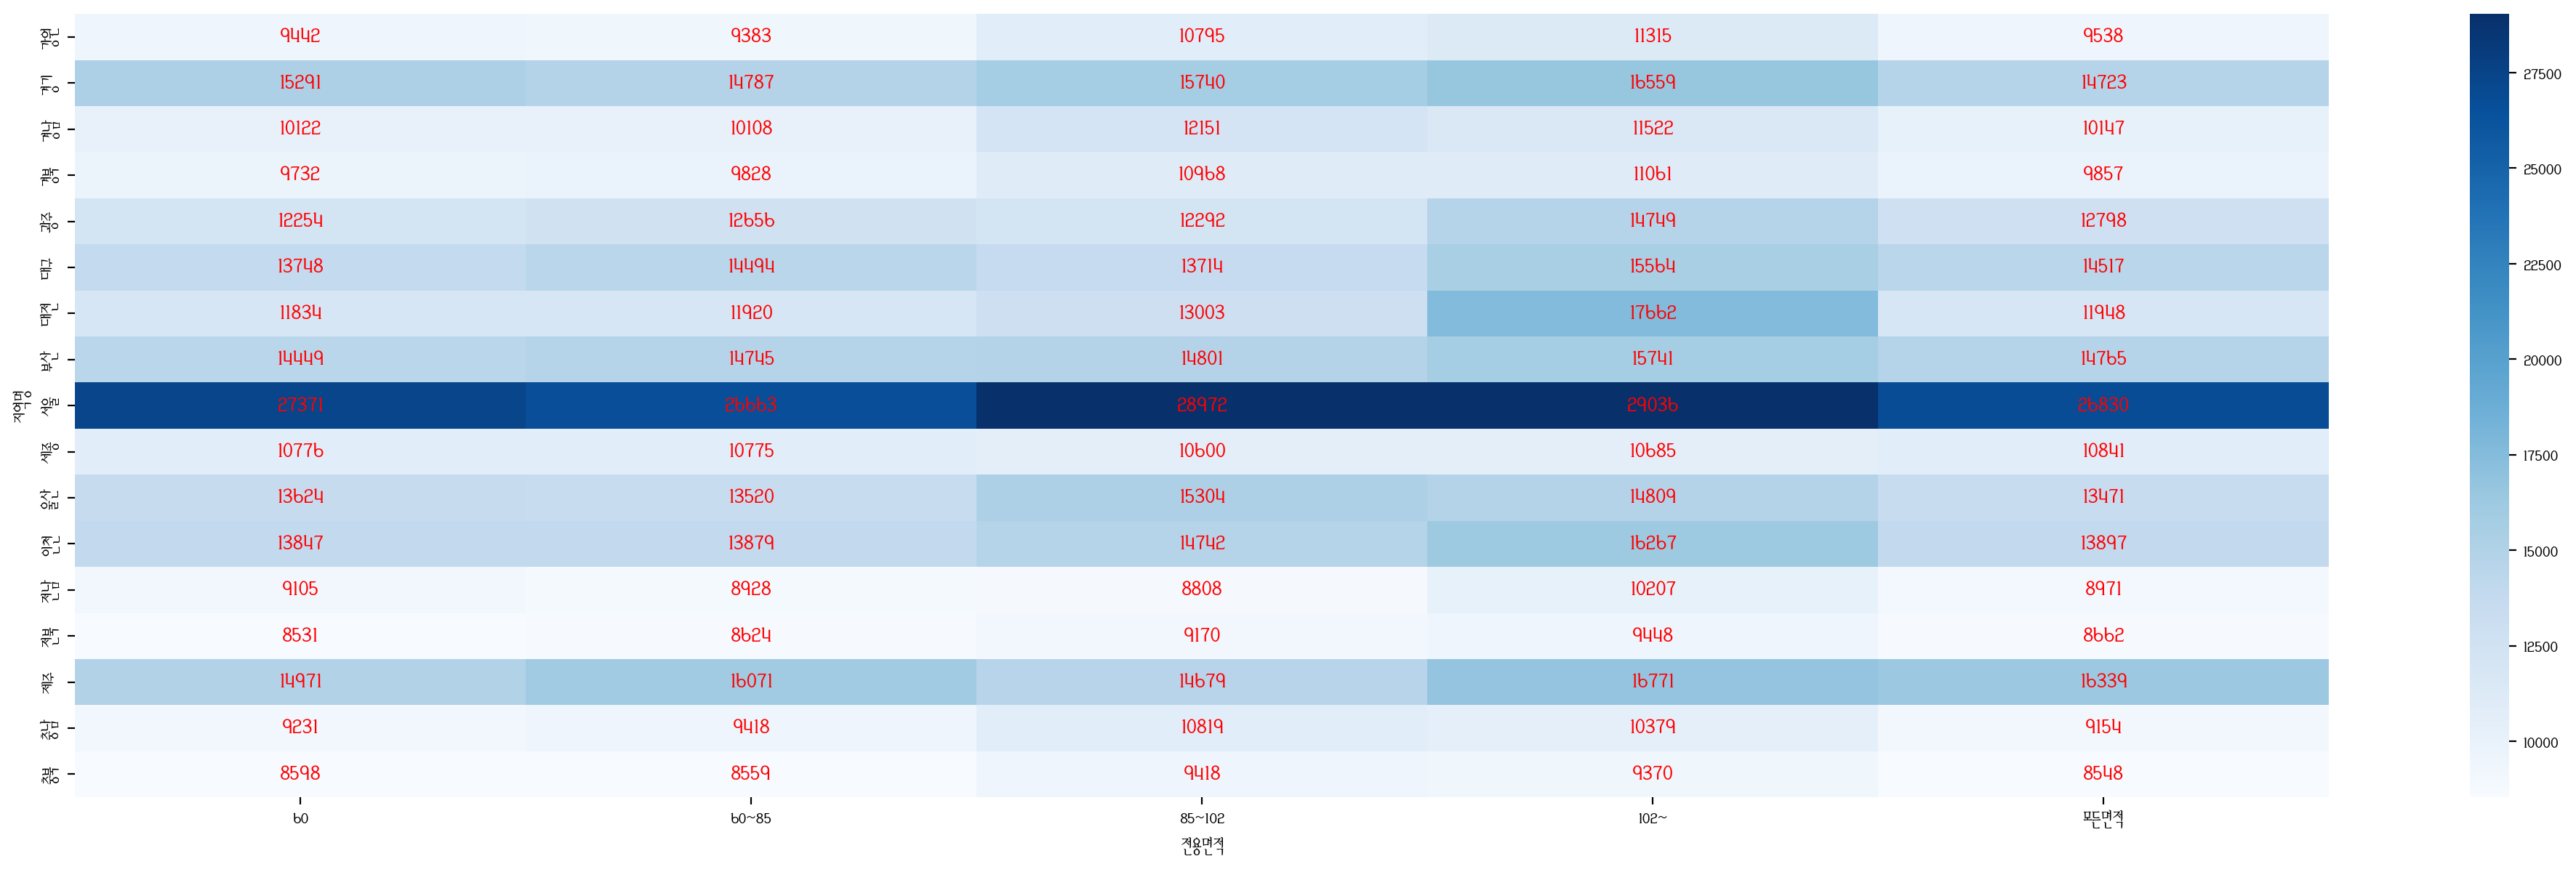

In [277]:
plt.figure(figsize=(25,7))
sns.heatmap(r, cmap='Blues', annot=True, fmt='.0f',
           annot_kws={'size':13, 'weight':'bold', 'color':'red'})

## (5) 연도, 지역별 평당분양가격(평균)

In [278]:
df_last.groupby(['연도', '지역명'])['평당분양가격'].mean().unstack()

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
연도,,,,,,,,,,,,,,,,,
2015,7188.060000,11060.940,8459.220000,7464.160000,7916.700000,9018.900000,8190.600000,10377.400000,20315.680000,8765.020000,9367.600000,10976.020000,6798.880000,7110.400000,7951.075000,7689.880000,6828.800000
2016,7162.903846,11684.970,8496.730000,7753.405000,9190.683333,10282.030000,8910.733333,10743.535000,21753.435000,8857.805000,9582.574138,11099.055000,6936.600000,6906.625000,9567.480000,7958.225000,7133.335000
2017,7318.850000,12296.185,8806.600000,8288.063793,9599.700000,12191.972222,9912.910526,11637.615000,21864.095000,9132.945763,10630.160870,11672.430000,7413.230000,7406.126316,12628.539623,8157.315517,7462.565000
2018,8219.255000,14258.420,9327.670000,8680.776923,9526.953333,12139.252632,10234.106667,12889.965000,23202.245000,10340.463158,10241.400000,11881.532143,7929.845000,8174.595000,11935.968000,8201.820000,8149.295000
2019,8934.475000,15665.540,10697.615789,9050.250000,12111.675000,14081.650000,12619.200000,13537.865000,28286.830000,11299.394118,10216.250000,13249.775000,8219.275862,8532.260000,11828.469231,8748.840000,7970.875000
2020,10302.423214,15106.080,10919.272222,9997.693750,13406.485714,15314.200000,11238.844737,13353.010000,29781.015000,11628.100000,12837.600000,14982.990000,9562.398214,8559.430000,14192.876923,9139.380000,8358.956897
2021,10291.325000,14567.080,11302.335000,11227.150000,13709.850000,15586.285000,11994.216667,14317.655000,29380.450000,12578.060000,14191.953061,15774.330000,9980.760000,9047.928814,22302.342857,9860.741379,8822.385000
2022,11644.215000,16621.550,12455.685000,12018.050000,15095.885106,16821.915000,14113.880000,18166.835593,29128.531034,11309.971698,17903.751724,17341.830000,10635.508475,10003.070000,18953.825000,11730.345000,10033.540000
2023,13409.385000,20175.210,13283.182759,13025.320000,17957.852830,17656.747059,17917.288889,20470.850847,33230.560000,12278.200000,18832.093220,16150.695000,11846.682692,10966.024528,24095.901923,12580.590000,11103.950000


In [281]:
df_last.pivot_table(index = ['연도', '지역명'],
                   values = '평당분양가격',
                   #aggfunc = 'mean'
                   ).unstack()
df_last.pivot_table(index = '연도',
                   columns= '지역명',
                   values = '평당분양가격',
                   #aggfunc = 'mean'
                   )

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
연도,,,,,,,,,,,,,,,,,
2015,7188.060000,11060.940,8459.220000,7464.160000,7916.700000,9018.900000,8190.600000,10377.400000,20315.680000,8765.020000,9367.600000,10976.020000,6798.880000,7110.400000,7951.075000,7689.880000,6828.800000
2016,7162.903846,11684.970,8496.730000,7753.405000,9190.683333,10282.030000,8910.733333,10743.535000,21753.435000,8857.805000,9582.574138,11099.055000,6936.600000,6906.625000,9567.480000,7958.225000,7133.335000
2017,7318.850000,12296.185,8806.600000,8288.063793,9599.700000,12191.972222,9912.910526,11637.615000,21864.095000,9132.945763,10630.160870,11672.430000,7413.230000,7406.126316,12628.539623,8157.315517,7462.565000
2018,8219.255000,14258.420,9327.670000,8680.776923,9526.953333,12139.252632,10234.106667,12889.965000,23202.245000,10340.463158,10241.400000,11881.532143,7929.845000,8174.595000,11935.968000,8201.820000,8149.295000
2019,8934.475000,15665.540,10697.615789,9050.250000,12111.675000,14081.650000,12619.200000,13537.865000,28286.830000,11299.394118,10216.250000,13249.775000,8219.275862,8532.260000,11828.469231,8748.840000,7970.875000
2020,10302.423214,15106.080,10919.272222,9997.693750,13406.485714,15314.200000,11238.844737,13353.010000,29781.015000,11628.100000,12837.600000,14982.990000,9562.398214,8559.430000,14192.876923,9139.380000,8358.956897
2021,10291.325000,14567.080,11302.335000,11227.150000,13709.850000,15586.285000,11994.216667,14317.655000,29380.450000,12578.060000,14191.953061,15774.330000,9980.760000,9047.928814,22302.342857,9860.741379,8822.385000
2022,11644.215000,16621.550,12455.685000,12018.050000,15095.885106,16821.915000,14113.880000,18166.835593,29128.531034,11309.971698,17903.751724,17341.830000,10635.508475,10003.070000,18953.825000,11730.345000,10033.540000
2023,13409.385000,20175.210,13283.182759,13025.320000,17957.852830,17656.747059,17917.288889,20470.850847,33230.560000,12278.200000,18832.093220,16150.695000,11846.682692,10966.024528,24095.901923,12580.590000,11103.950000


<Axes: xlabel='전용면적', ylabel='지역명'>

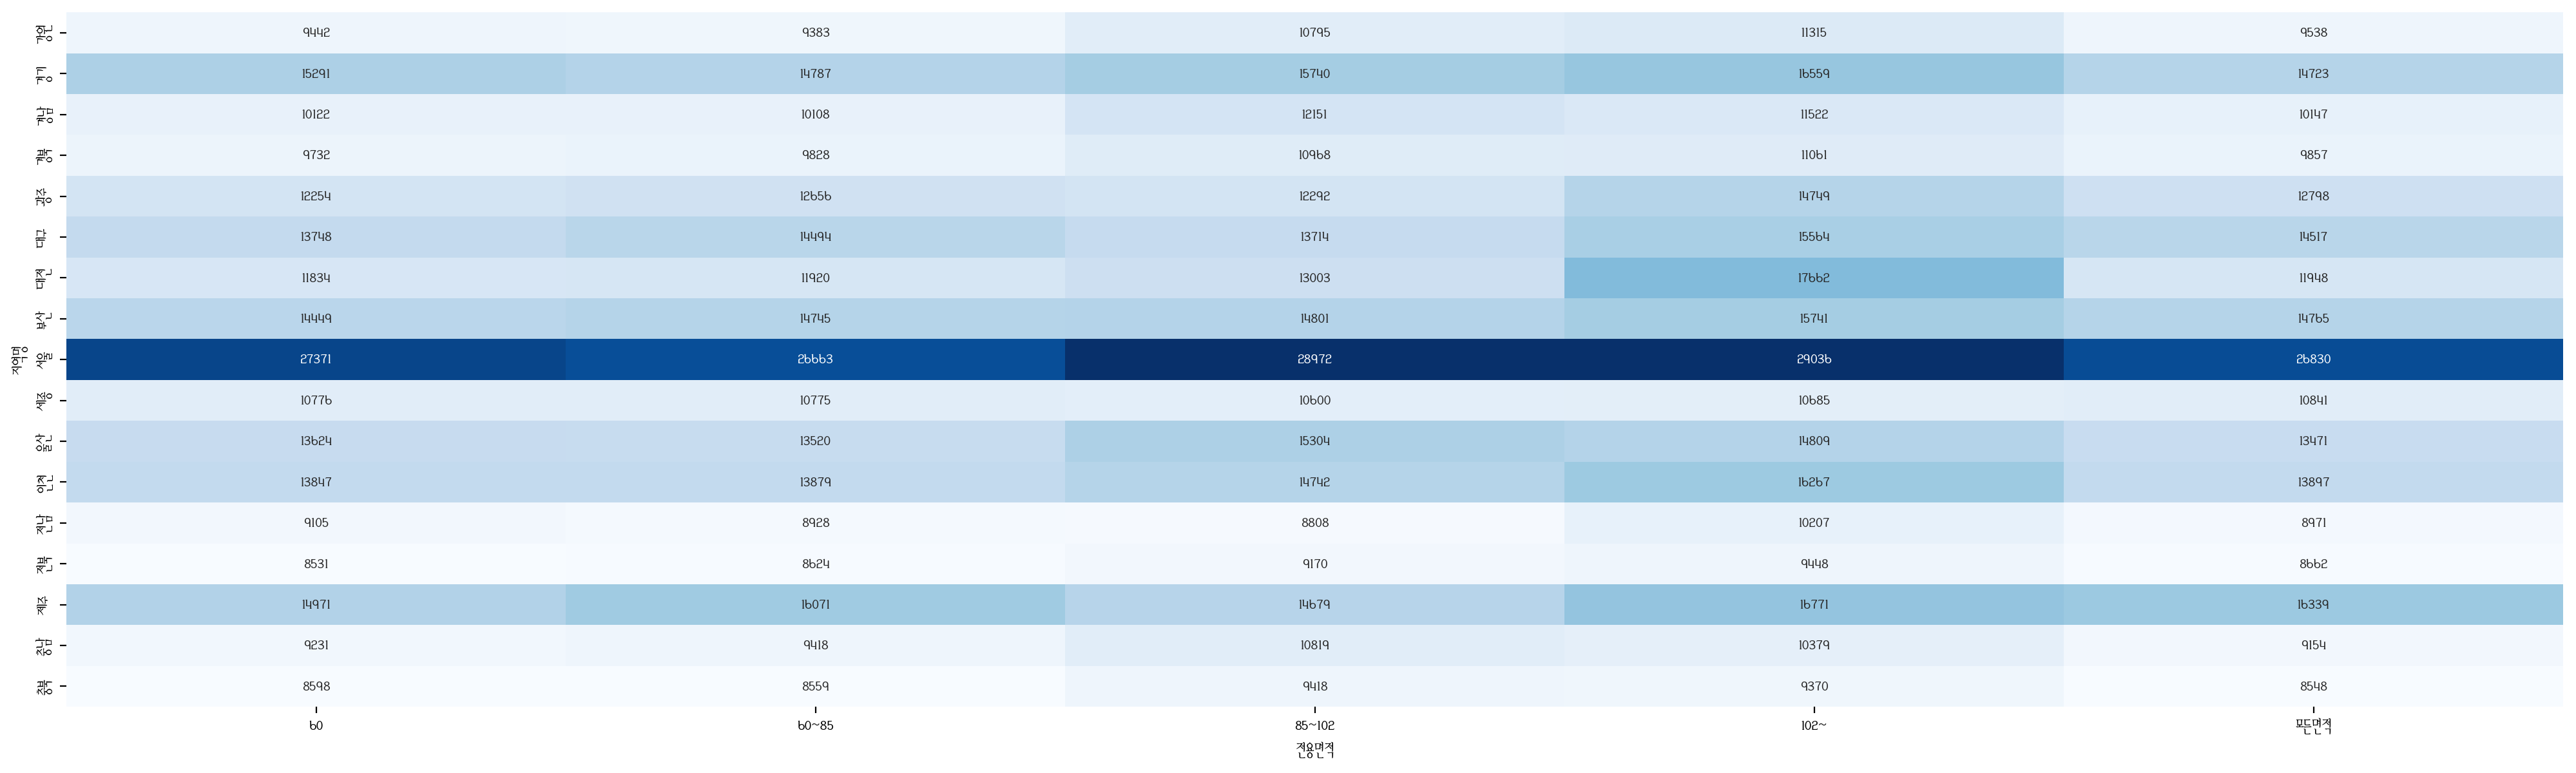

In [284]:
plt.figure(figsize=(25,7))
sns.heatmap(r,annot=True, fmt='.0f', cmap='Blues',
           annot_kws={'weight':'bold'},
           cbar=False)

- color map 참조 : https://matplotlib.org/stable/users/explain/colors/colormaps.html

# 8. matplotlib으로 시각화(위의 도표)
https://www.research.autodesk.com/publications/same-stats-different-graphs/
## (1) 지역별 결측치를 제외한 데이터수(line, bar)

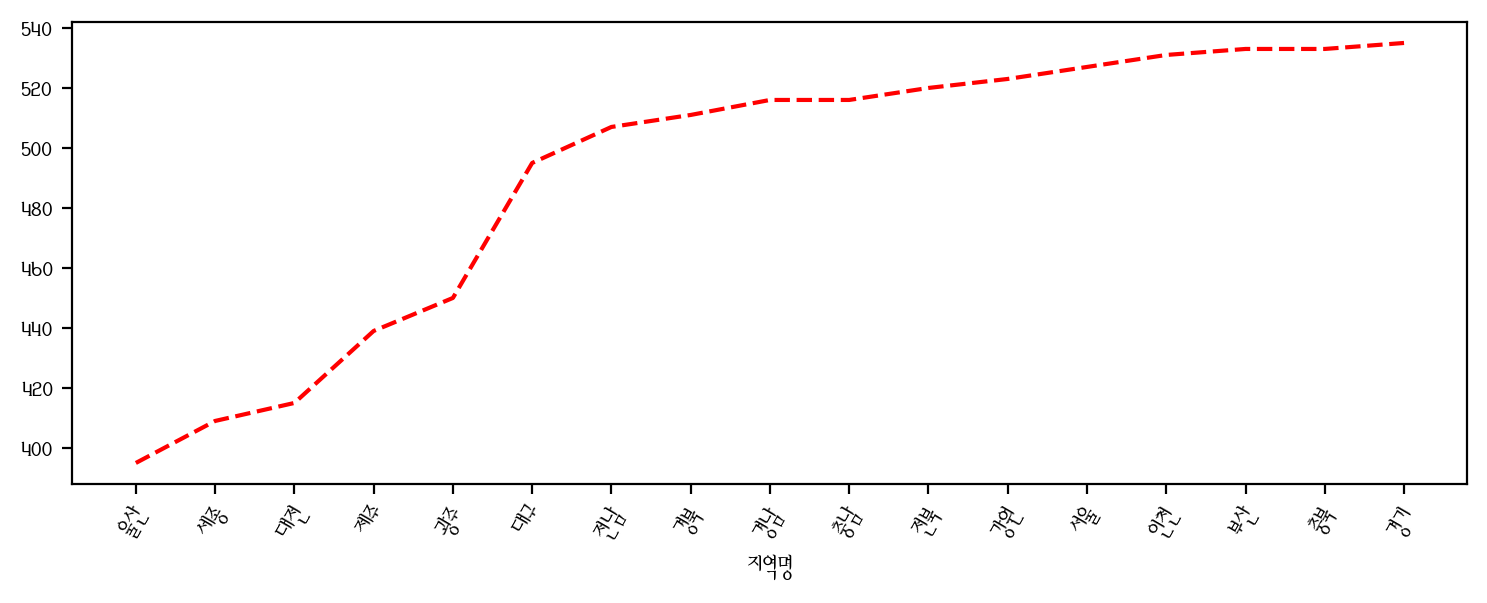

In [295]:
result = df_last.groupby('지역명')['평당분양가격'].count().sort_values()
#result.plot(kind='line')
ax = result.plot.line(figsize=(9,3), color = 'r', linestyle='--')
ax.set_xticks(range(len(result)))
ax.set_xticklabels(result.index, rotation=60)
plt.show()

<Axes: xlabel='지역명'>

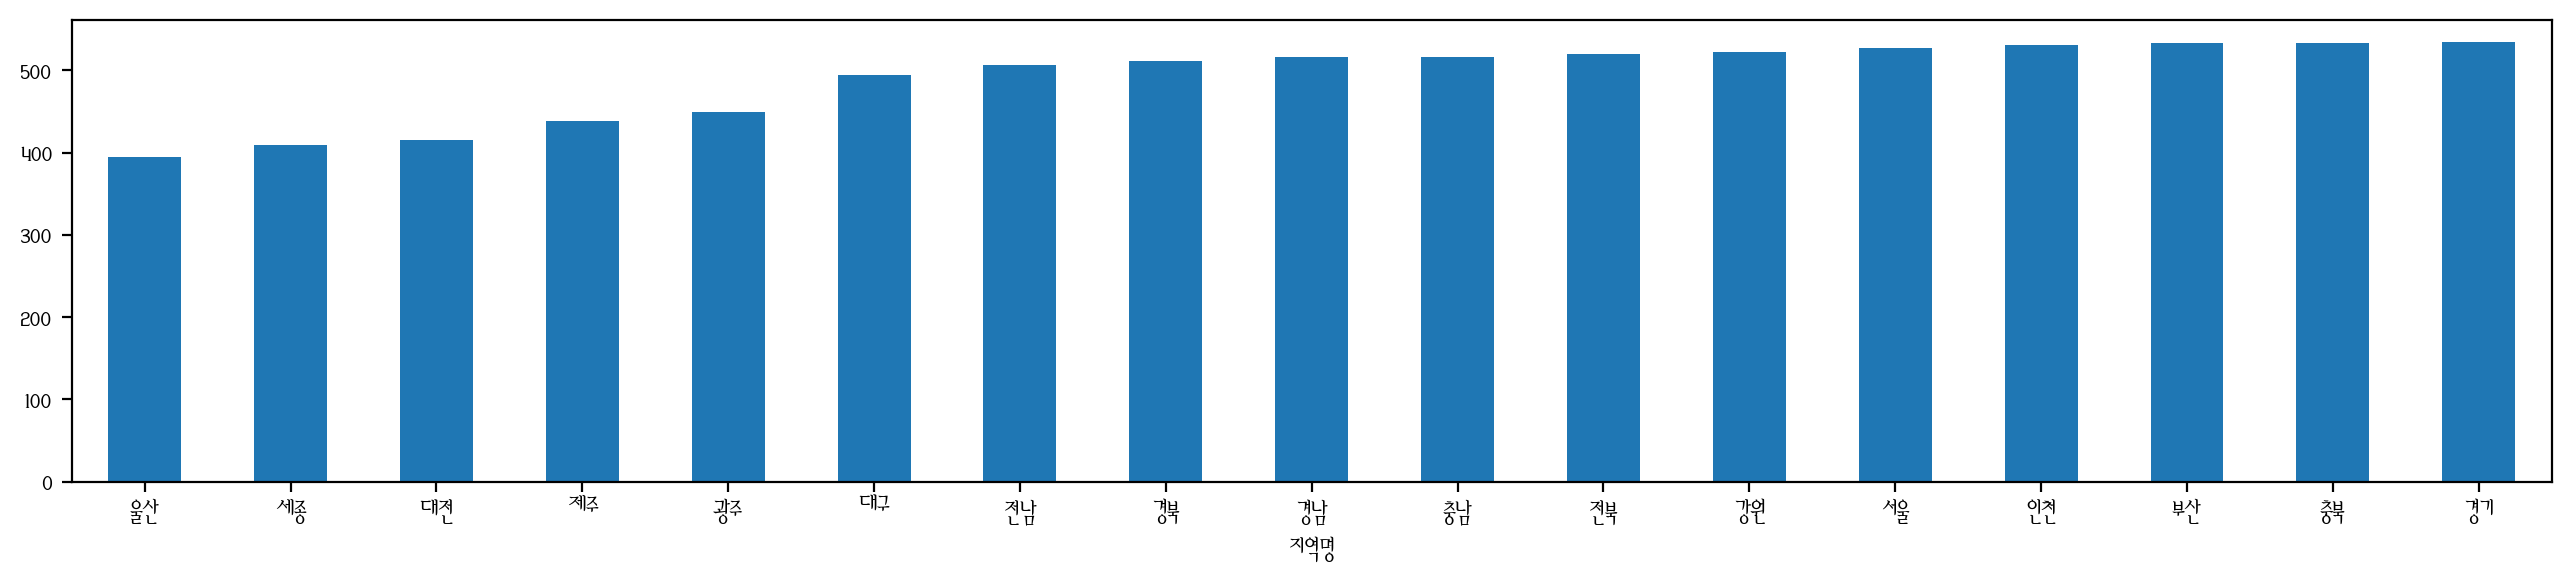

In [297]:
result.plot.bar()
result.plot(kind='bar', figsize=(16,3), rot=0)

## (2) 지역별 평당분양가격 (line, bar)

<Axes: xlabel='지역명'>

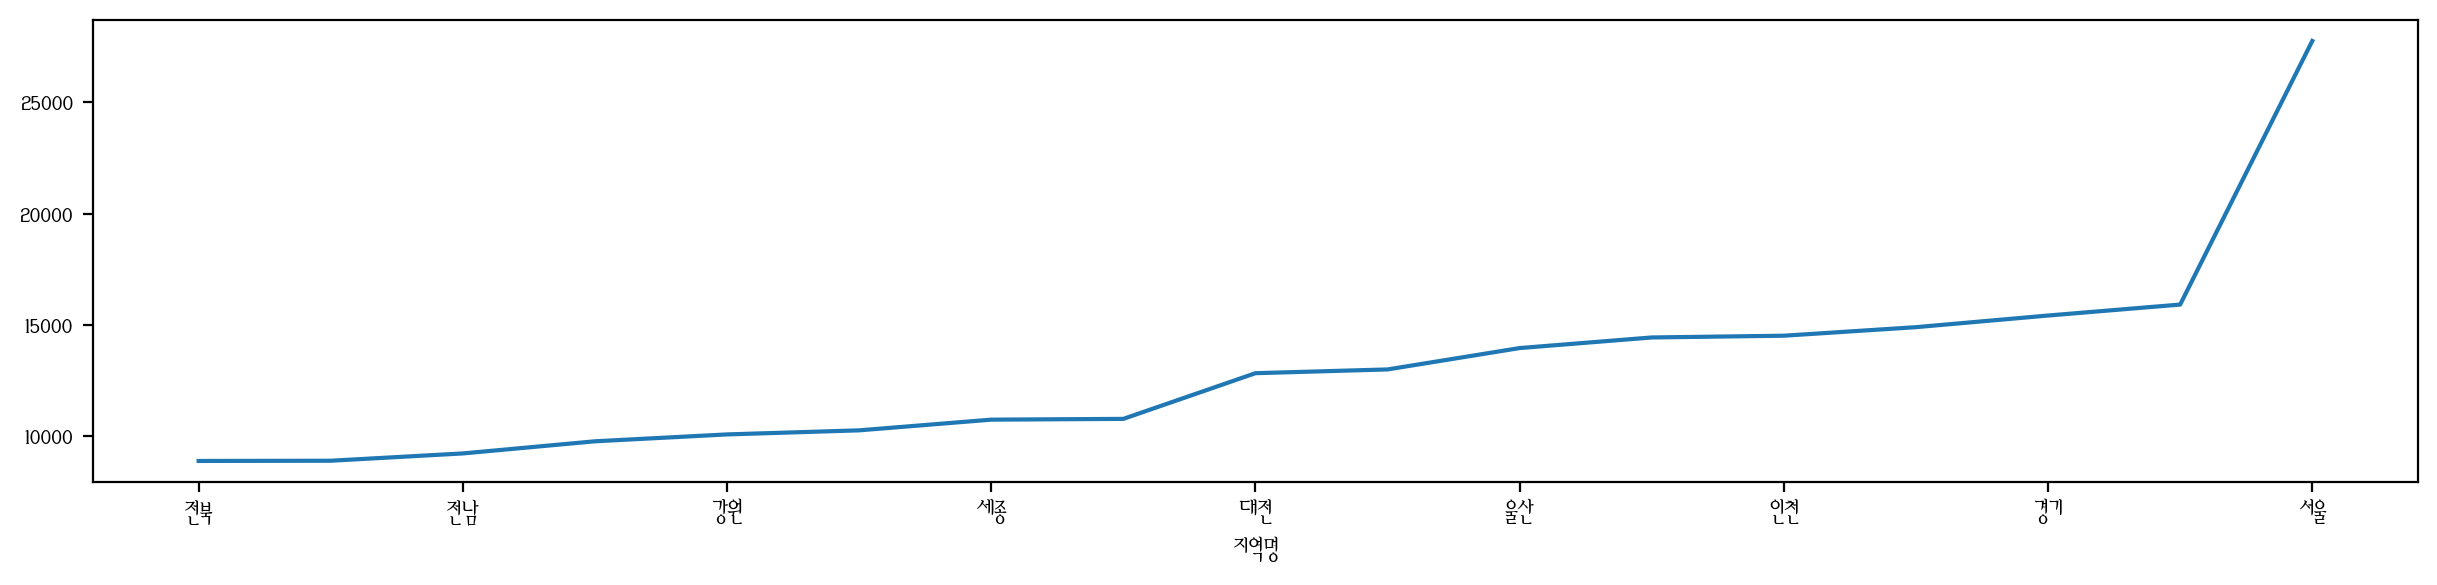

In [301]:
df_last.groupby('지역명')['평당분양가격'].mean().sort_values().plot(kind='line', figsize=(15,3))

<Axes: xlabel='지역명'>

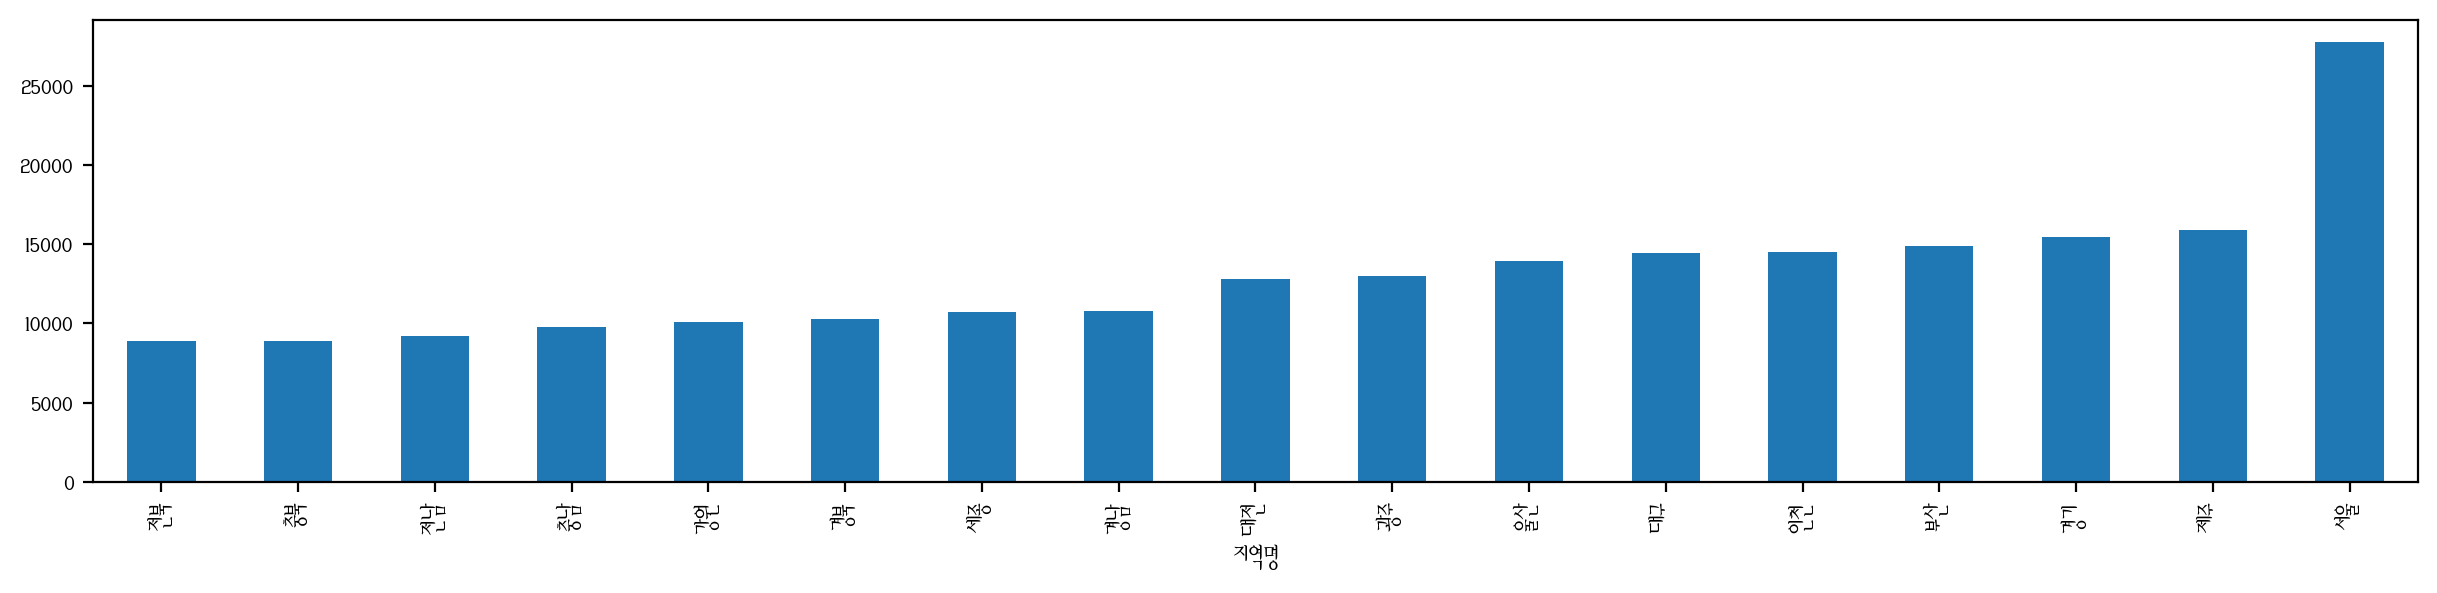

In [302]:
df_last.groupby('지역명')['평당분양가격'].mean().sort_values().plot(kind='bar', figsize=(15,3))

## (3) 전용면적별 평당분양가격(barplot)

In [306]:
result = df_last.groupby('전용면적')['평당분양가격'].mean().sort_values()
result

전용면적
60        12522.774427
60~85     12619.048827
모든면적      12654.068098
85~102    13447.672835
102~      14066.826846
Name: 평당분양가격, dtype: float64

In [ ]:
for idx, val in enumerate(result):
    print(idx, val)

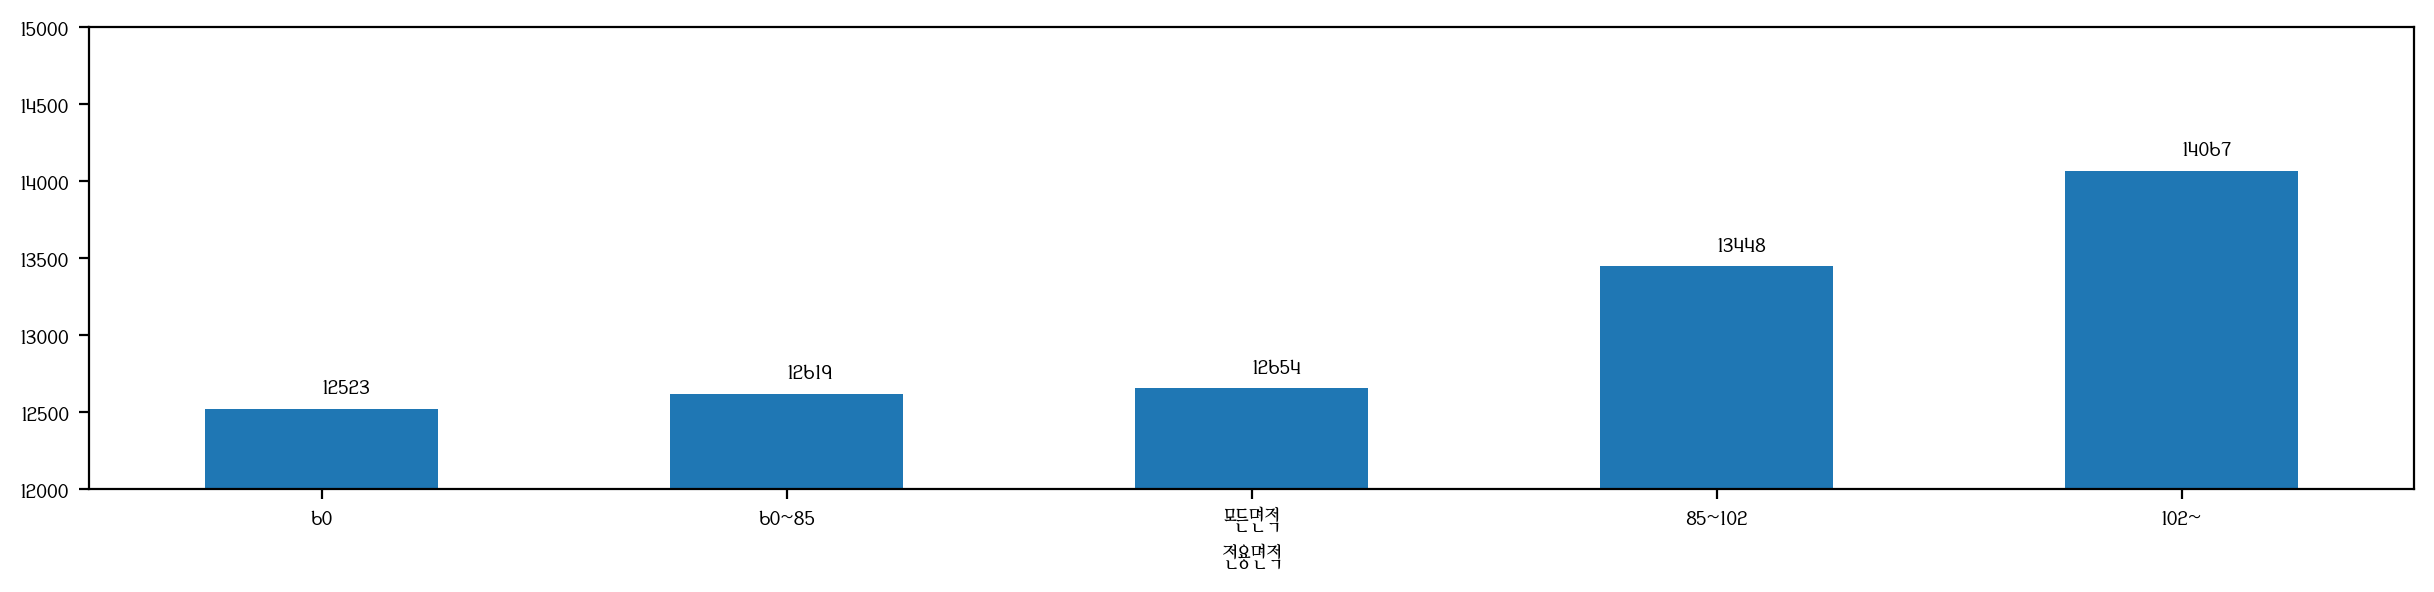

In [316]:
#result.plot.bar()
ax = result.plot(kind='bar', figsize=(15,3), rot=0)
ax.set_ylim([12000, 15000])
#ax.text(4,14066+100, 14066)
for idx, val in enumerate(result):
    ax.text(idx, val+100, round(val))

## (4) 연도별 평균 평당분양가격(line)

In [334]:
result = df_last.groupby('연도')['평당분양가격'].mean()
result

연도
2015     9202.735802
2016     9683.025000
2017    10372.928923
2018    10978.938411
2019    12188.293092
2020    13039.422449
2021    13636.022540
2022    14942.504494
2023    16890.920657
2024    18962.919231
Name: 평당분양가격, dtype: float64

In [335]:
for year, val in result.items():
    print(year, val)

2015 9202.735802469135
2016 9683.025
2017 10372.928923076923
2018 10978.938411316649
2019 12188.293092105261
2020 13039.42244897959
2021 13636.022539682539
2022 14942.504494382021
2023 16890.92065677966
2024 18962.91923076923


In [336]:
for year, val in zip(result.index, result):
    print(year,val)

2015 9202.735802469135
2016 9683.025
2017 10372.928923076923
2018 10978.938411316649
2019 12188.293092105261
2020 13039.42244897959
2021 13636.022539682539
2022 14942.504494382021
2023 16890.92065677966
2024 18962.91923076923


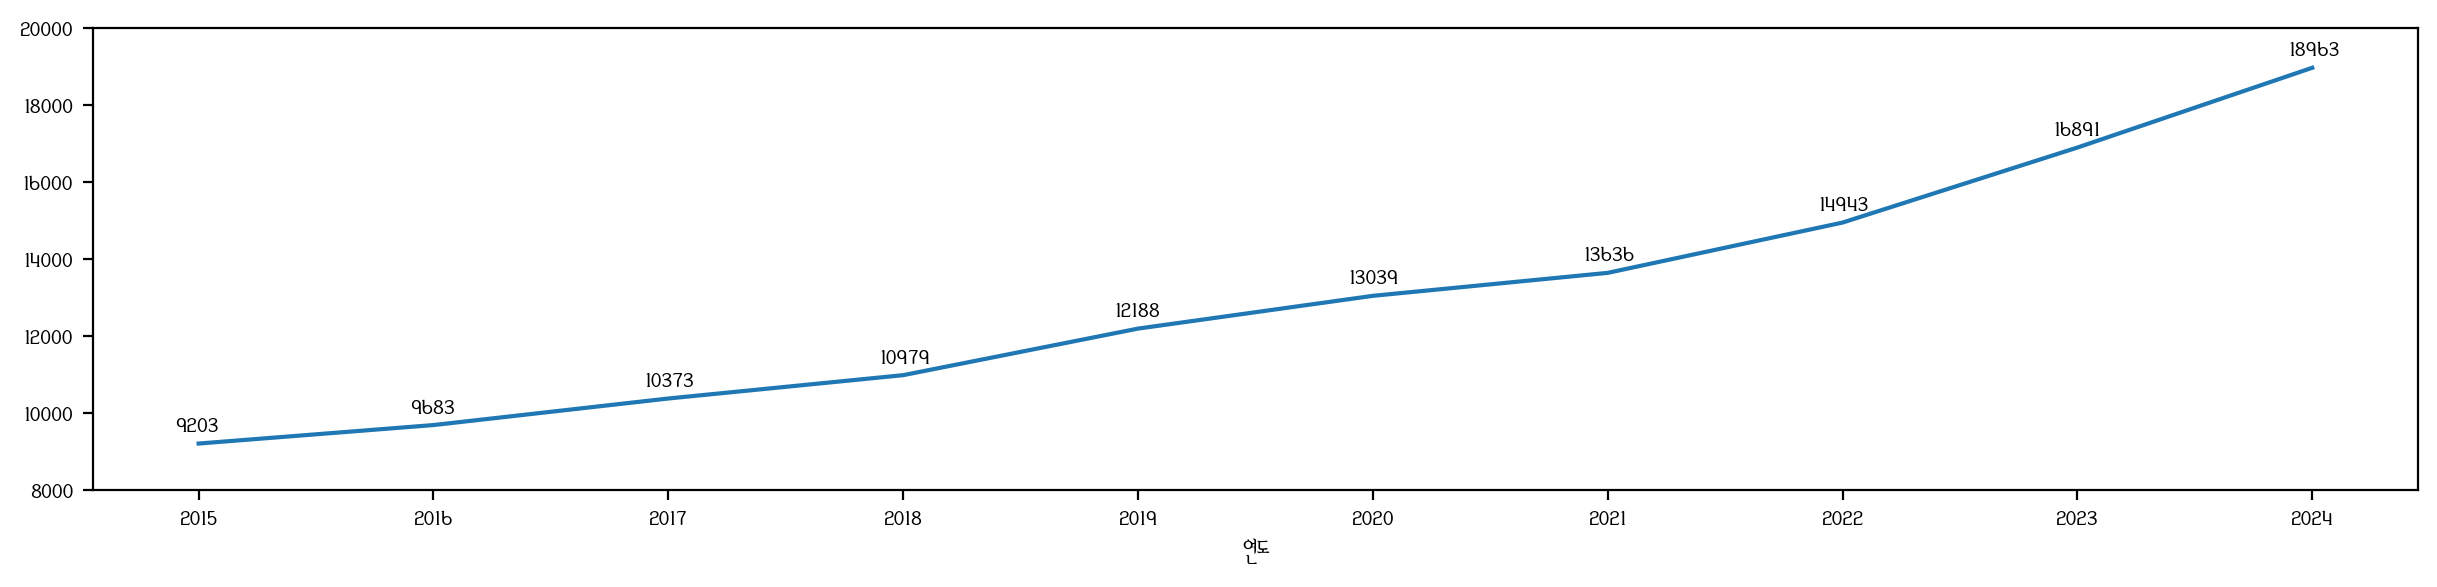

In [337]:
#result.plot.line()
result.plot(kind='line', figsize=(15,3))
plt.ylim([8000, 20000])
#plt.xlim([2015, 2025]) #x축 구간
plt.xticks(range(2015, 2025))
#plt.text(2015-0.1, 9202+300, 9202) for문으로 연결
for year, val in result.items():
    plt.text(year-0.1, val+300, round(val))
plt.show()

범례:https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot

# 9. seaborn으로 시각화
- 위에서 시각화한 내용을 seaborn으로 시각화

In [ ]:
sns.set(style='white', rc={'figure.figsize':(9,3)})
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

## (1) 지역별 평당분양가격

<Axes: xlabel='지역명', ylabel='평당분양가격'>

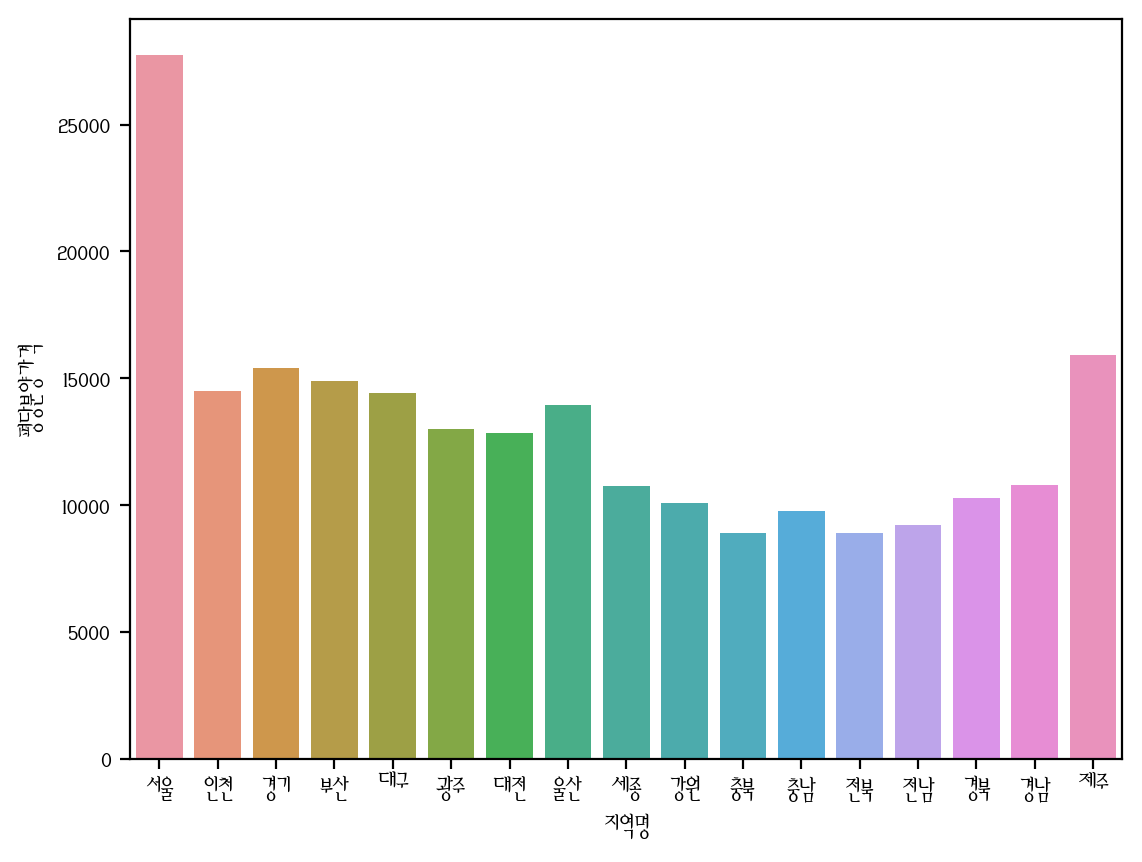

In [339]:
sns.barplot(data=df_last, x='지역명', y='평당분양가격',
           #errorbar='sd'#표준편차, 가본값은 95%신뢰구간
            errorbar=None
           )

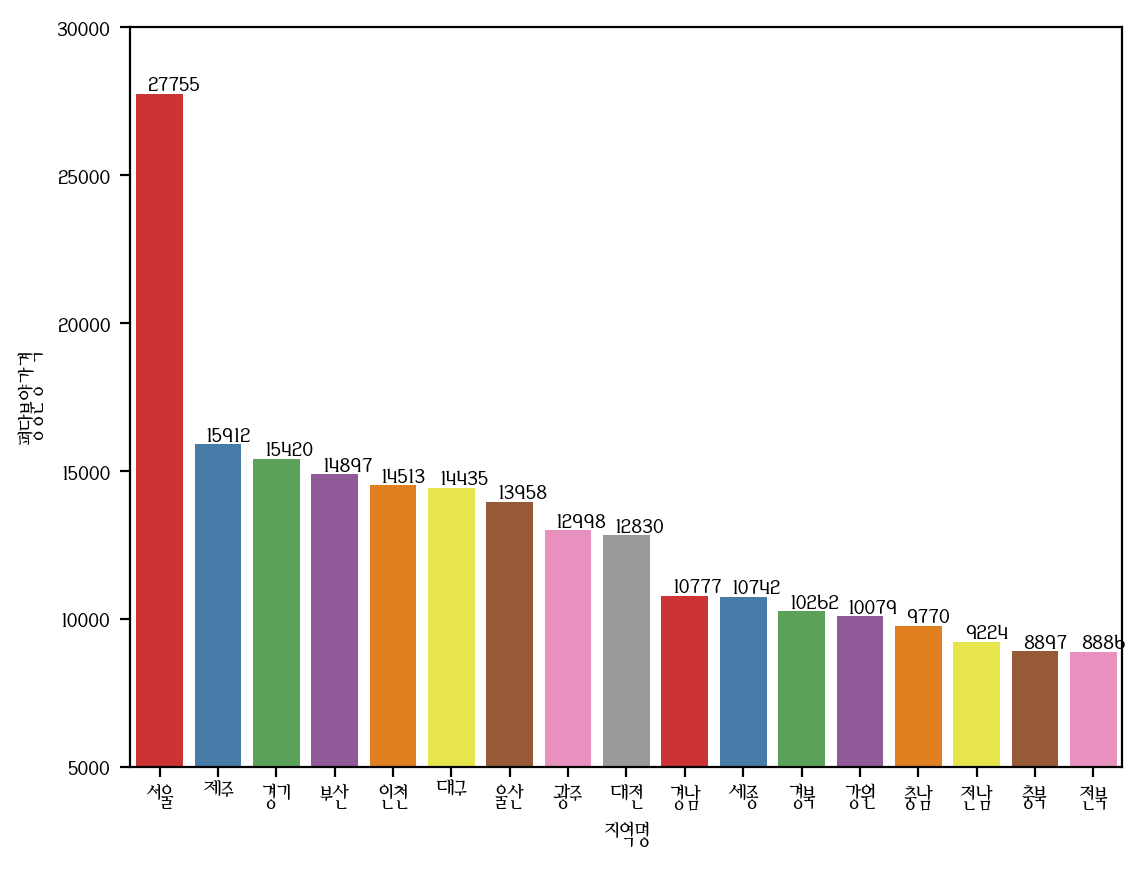

In [350]:
# 위 barplot + sort
result = df_last.groupby('지역명')['평당분양가격'].mean().sort_values(ascending=False)
result.index
sns.barplot(data=df_last, x='지역명', y='평당분양가격', 
           order=result.index,
           errorbar=None,
           palette='Set1')
for idx, val in enumerate(result):
    plt.text(idx-0.2, val+100, round(val))
plt.ylim([5000,30000])
plt.show()

In [347]:
for idx, val in enumerate(result):
    print(idx,val)

0 27755.404554079694
1 15912.434624145786
2 15420.03028037383
3 14896.949155722325
4 14513.23220338983
5 14434.519999999999
6 13958.197974683544
7 12998.215999999999
8 12829.565060240964
9 10776.95581395349
10 10741.830806845965
11 10261.553424657533
12 10078.71739961759
13 9769.541279069766
14 9224.326627218934
15 8896.58330206379
16 8886.201923076924


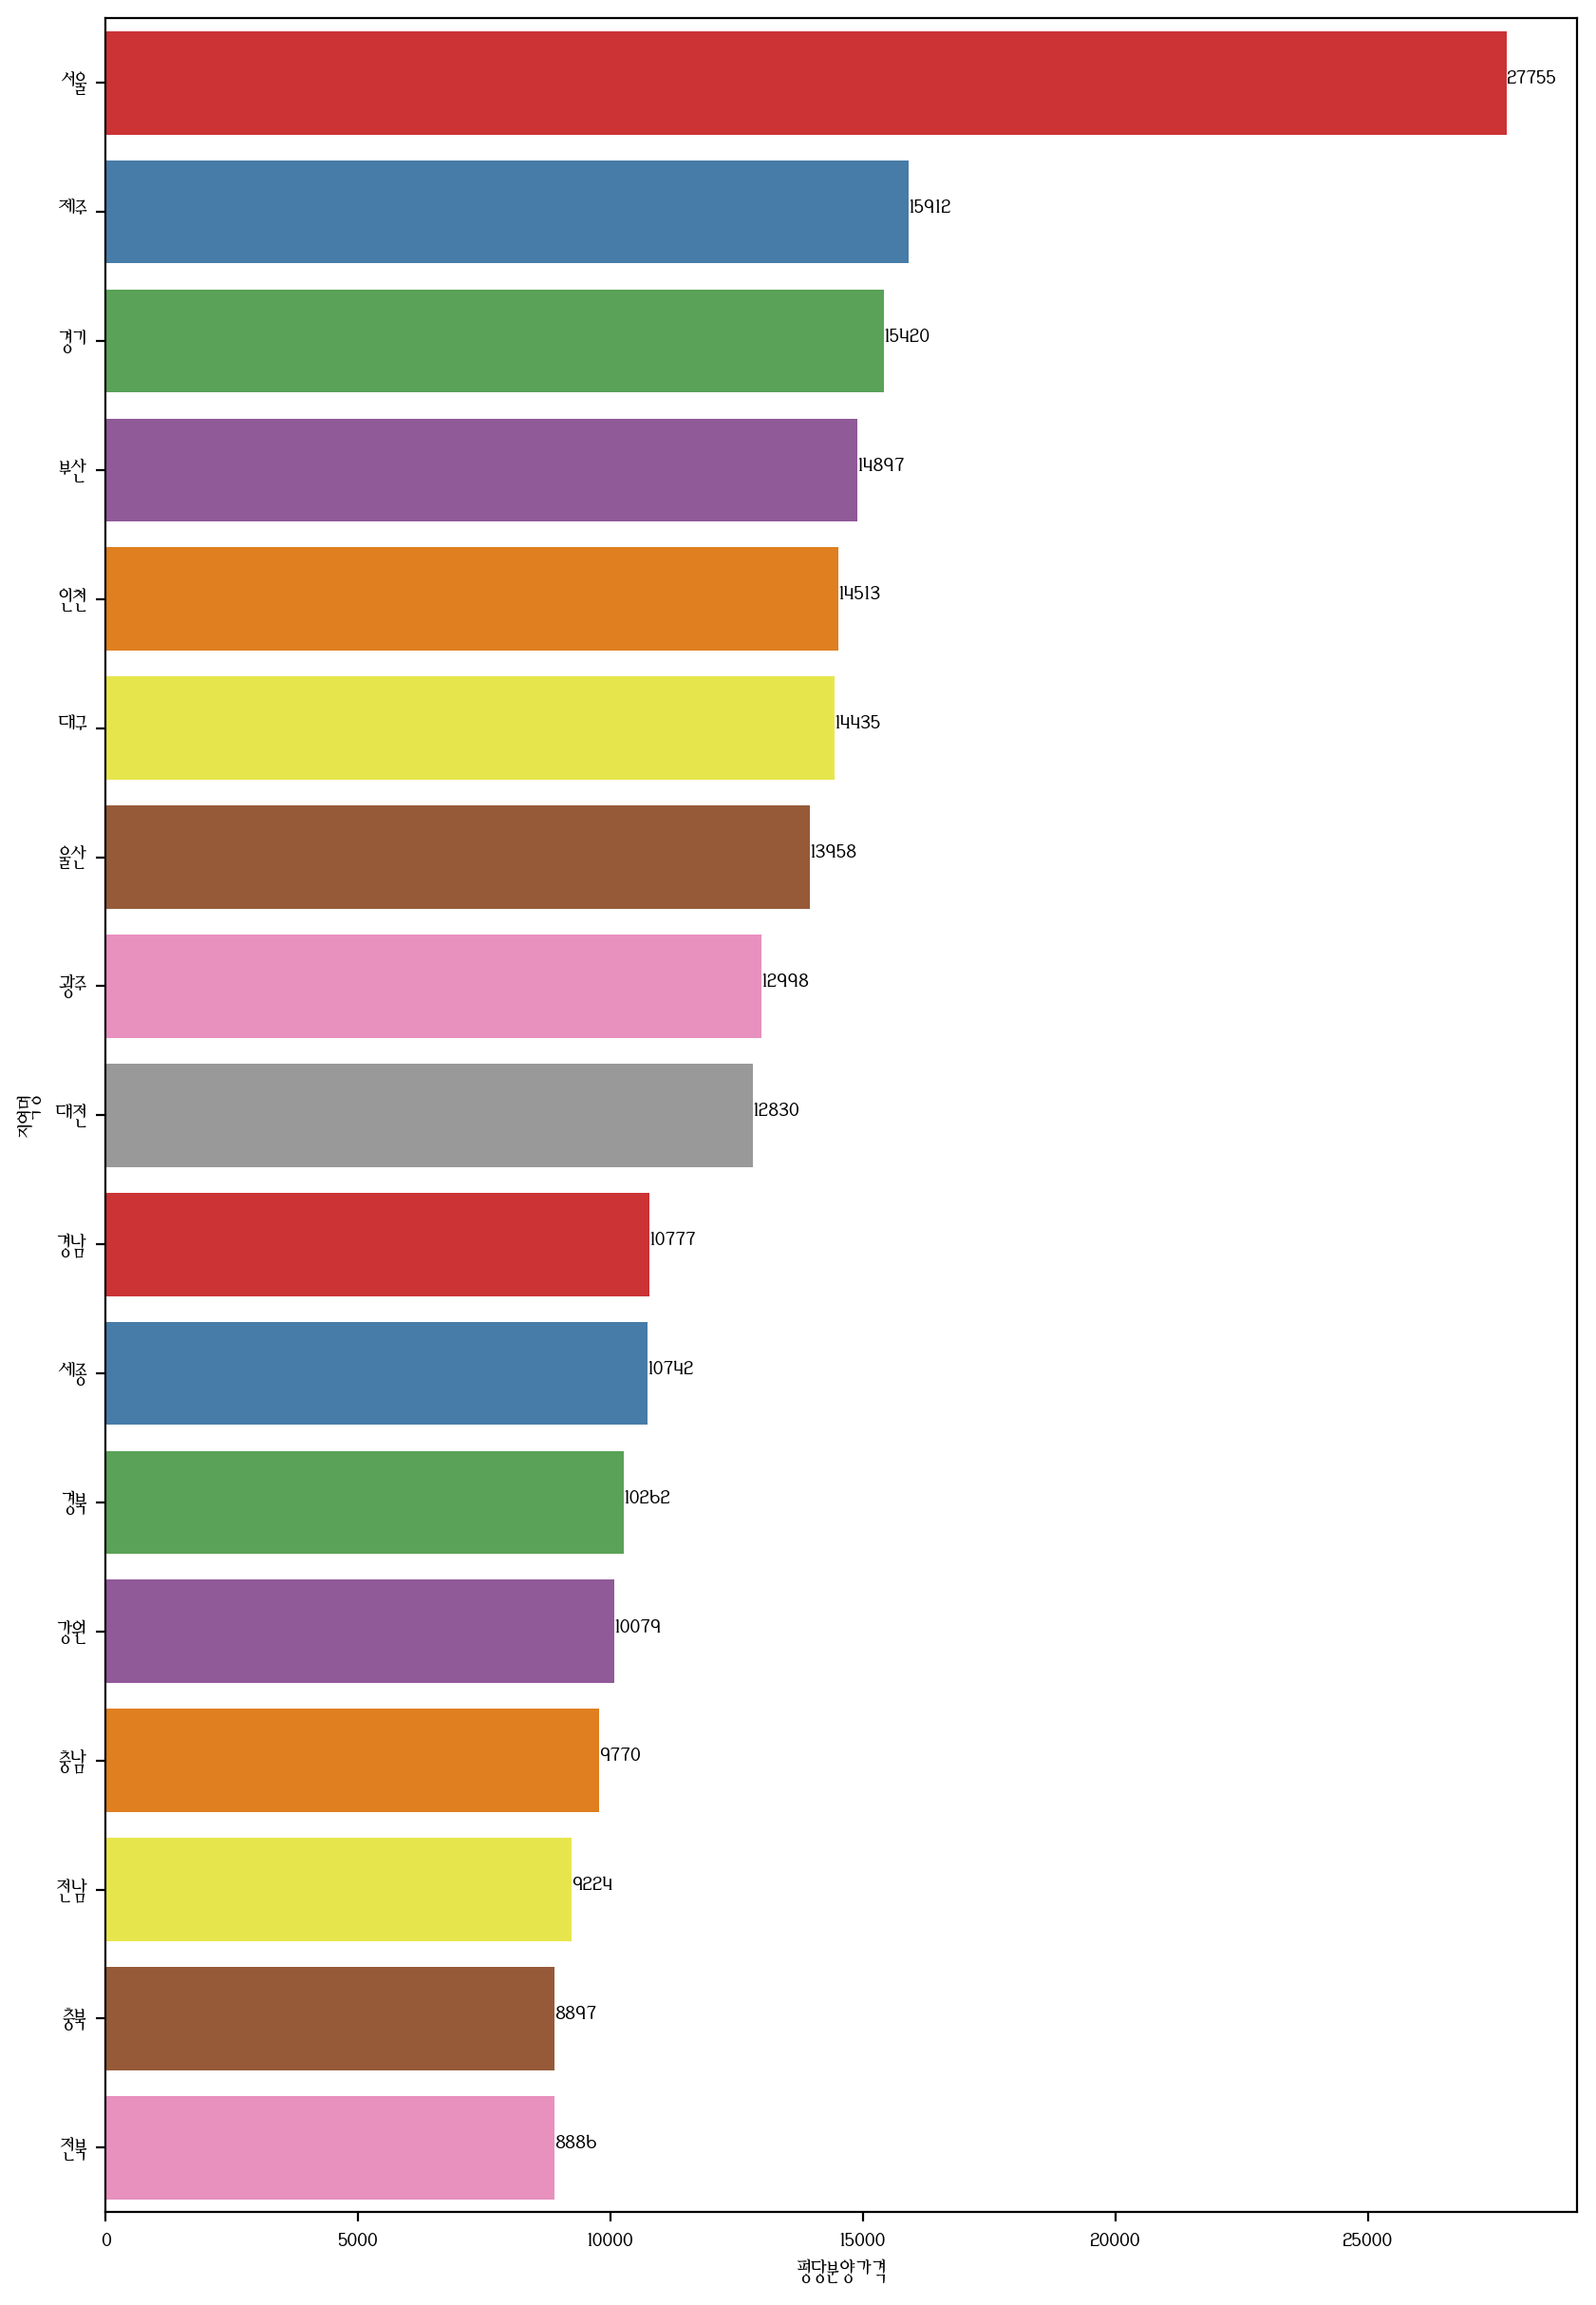

In [356]:
# 가로 barplot
plt.figure(figsize=(10, 15))
result = df_last.groupby('지역명')['평당분양가격'].mean().sort_values(ascending=False)
result.index
sns.barplot(data=df_last, y='지역명', x='평당분양가격', 
           order=result.index,
           errorbar=None,
           palette='Set1')
for idx, val in enumerate(result):
     plt.text(val, idx, round(val))
plt.show()

## (2) 연도별 평당분양가격

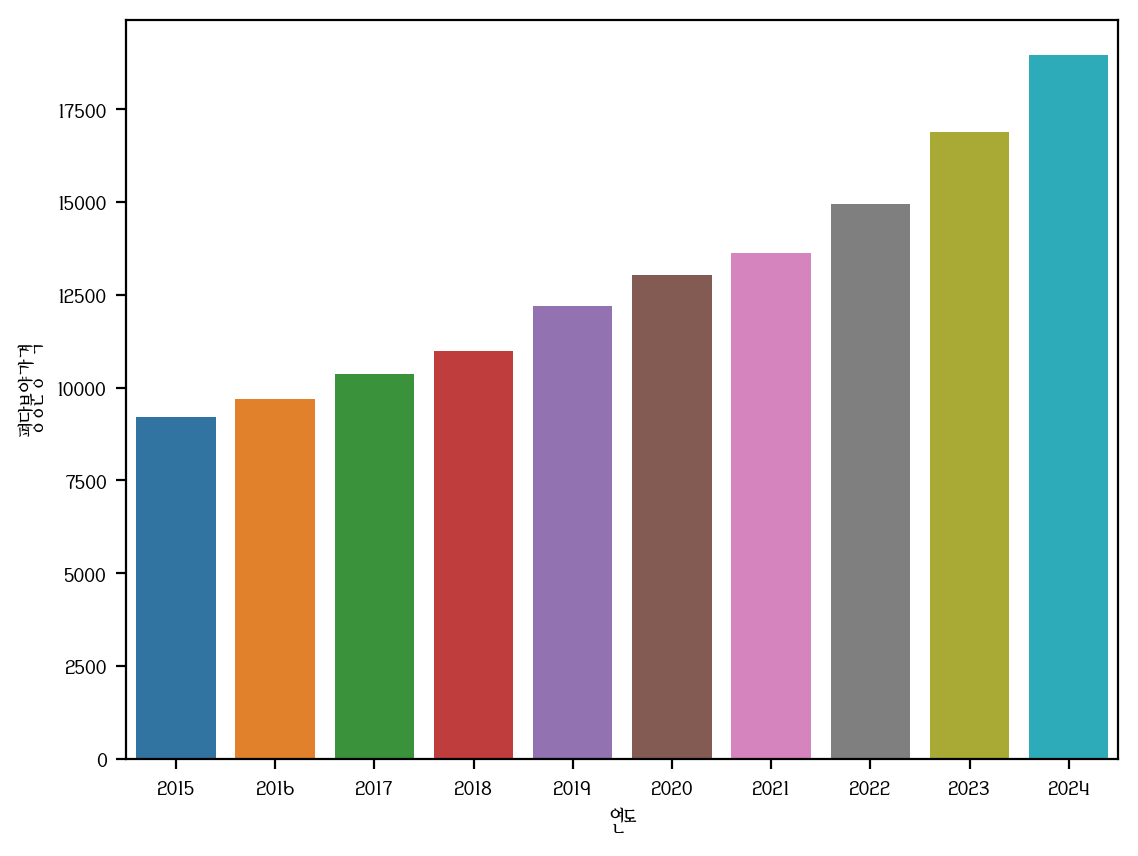

In [359]:
sns.barplot(data=df_last, x='연도', y='평당분양가격', errorbar=None)
plt.show()

## (3) 그 외 lineplot, relplot, boxplot, violinplot, boxexplot, regplot, swarmplot

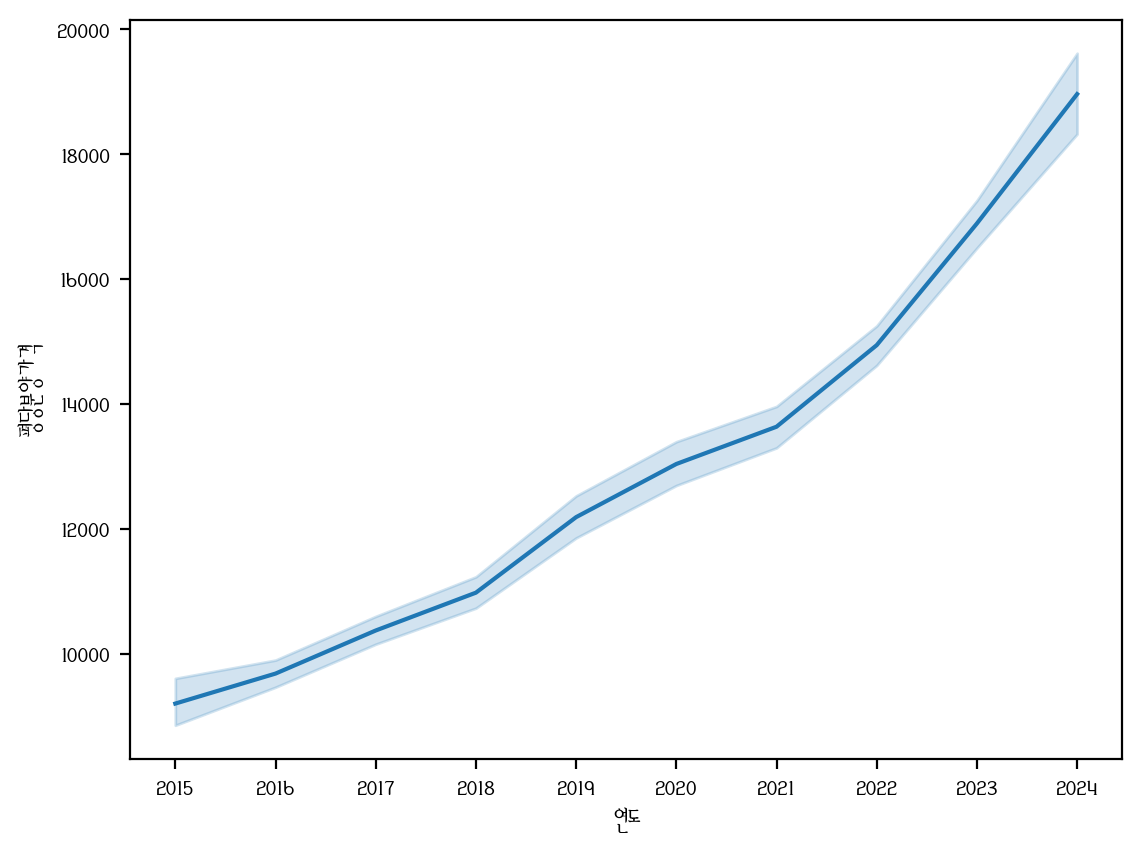

In [362]:
#년도별 평당분양가격의 추기(lineplot)
sns.lineplot(data=df_last, x='연도', y='평당분양가격')
plt.xticks(range(2015, 2025))
plt.show()

https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot : 범례사용(교안 20page)

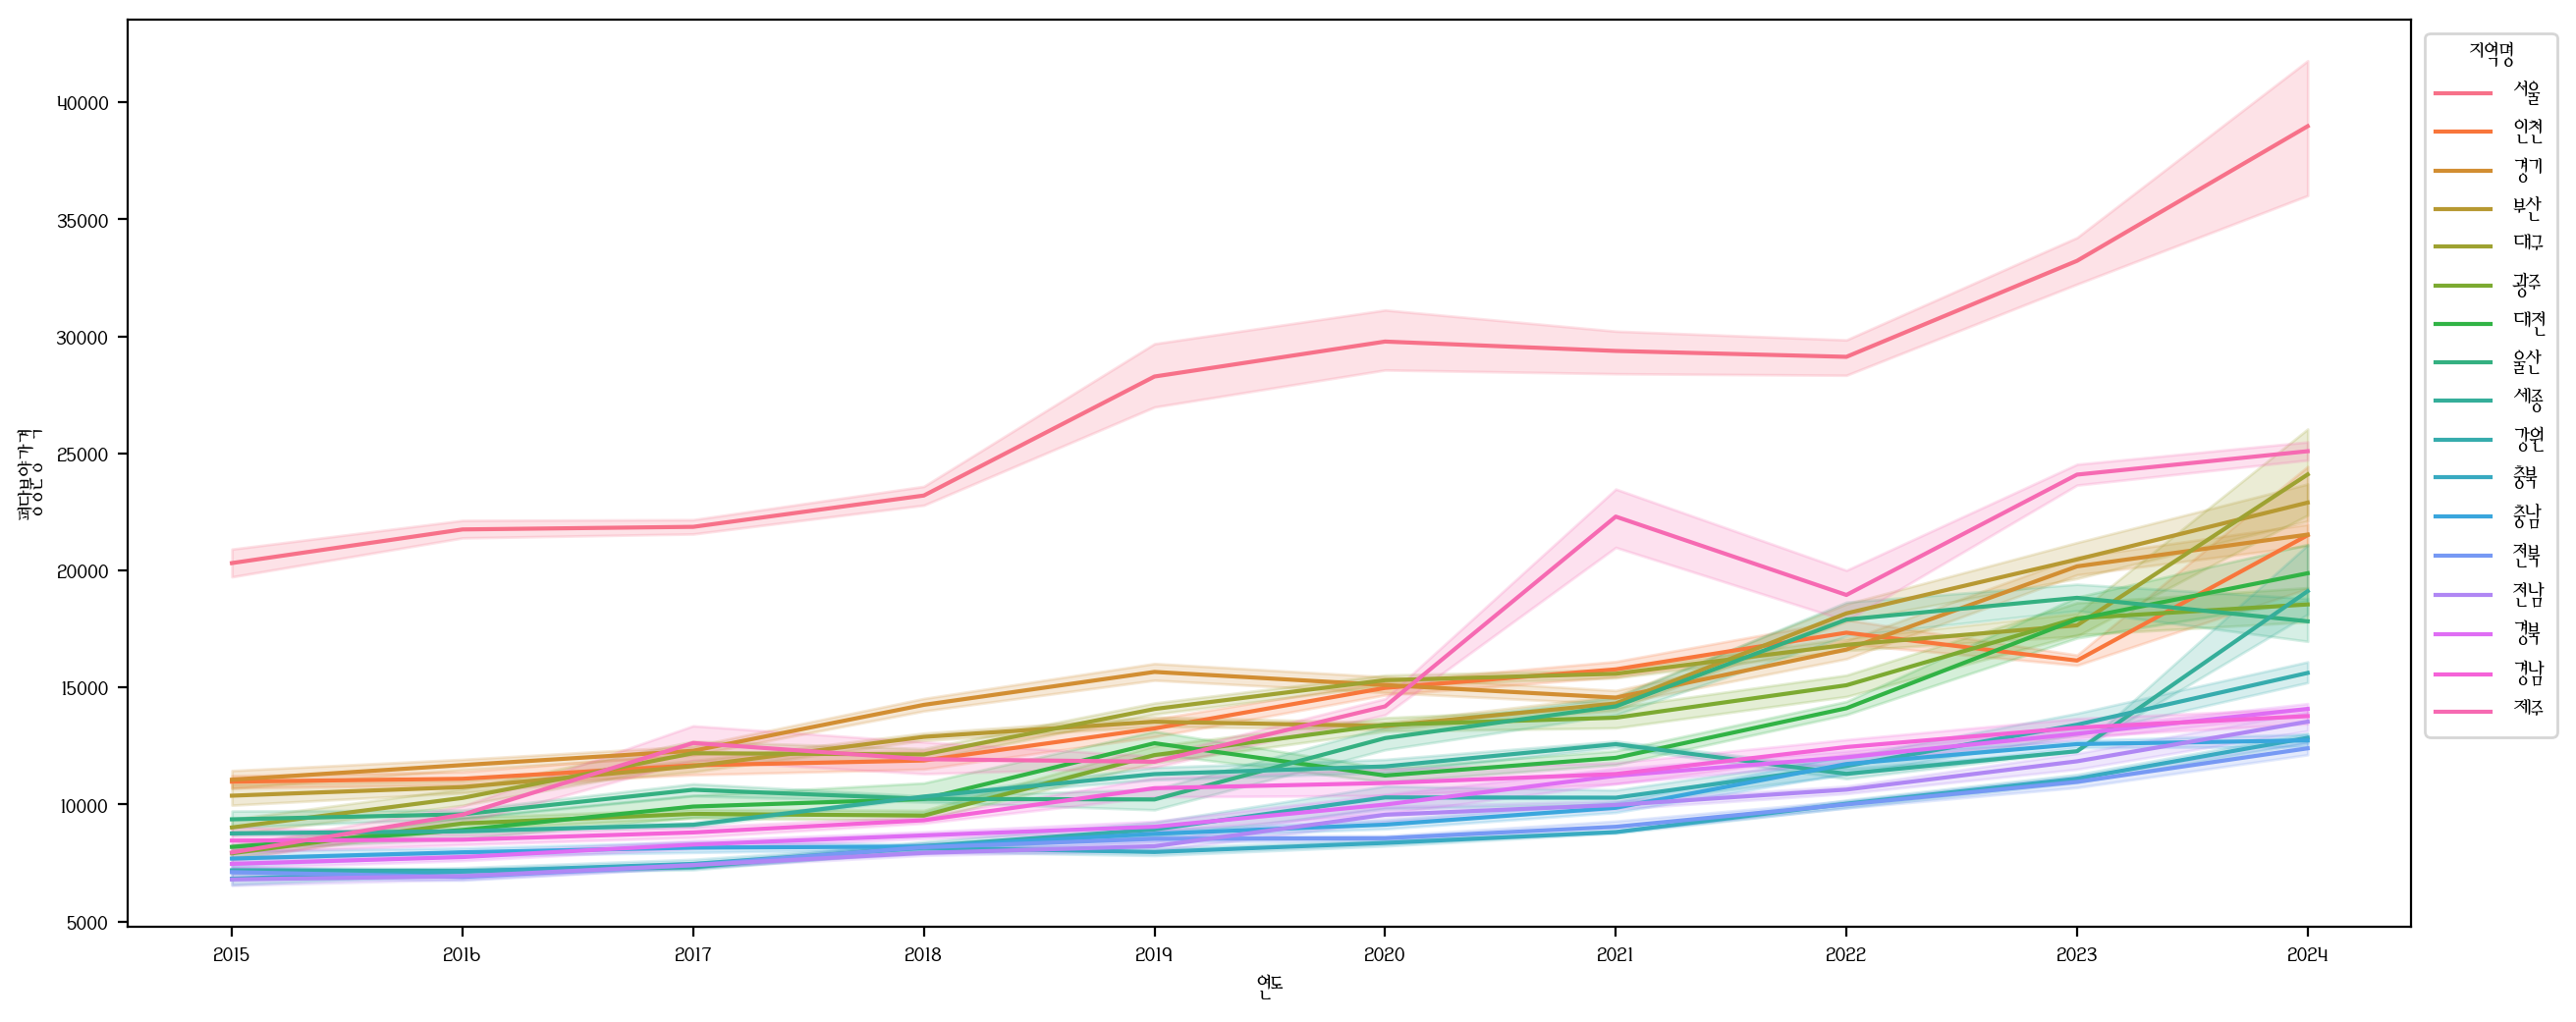

In [366]:
#지역별 평당분양가격의 추이(lineplot)
plt.figure(figsize=(15,6))
ax = sns.lineplot(data=df_last, x='연도', y='평당분양가격', hue='지역명')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.xticks(range(2015, 2025))
plt.show()

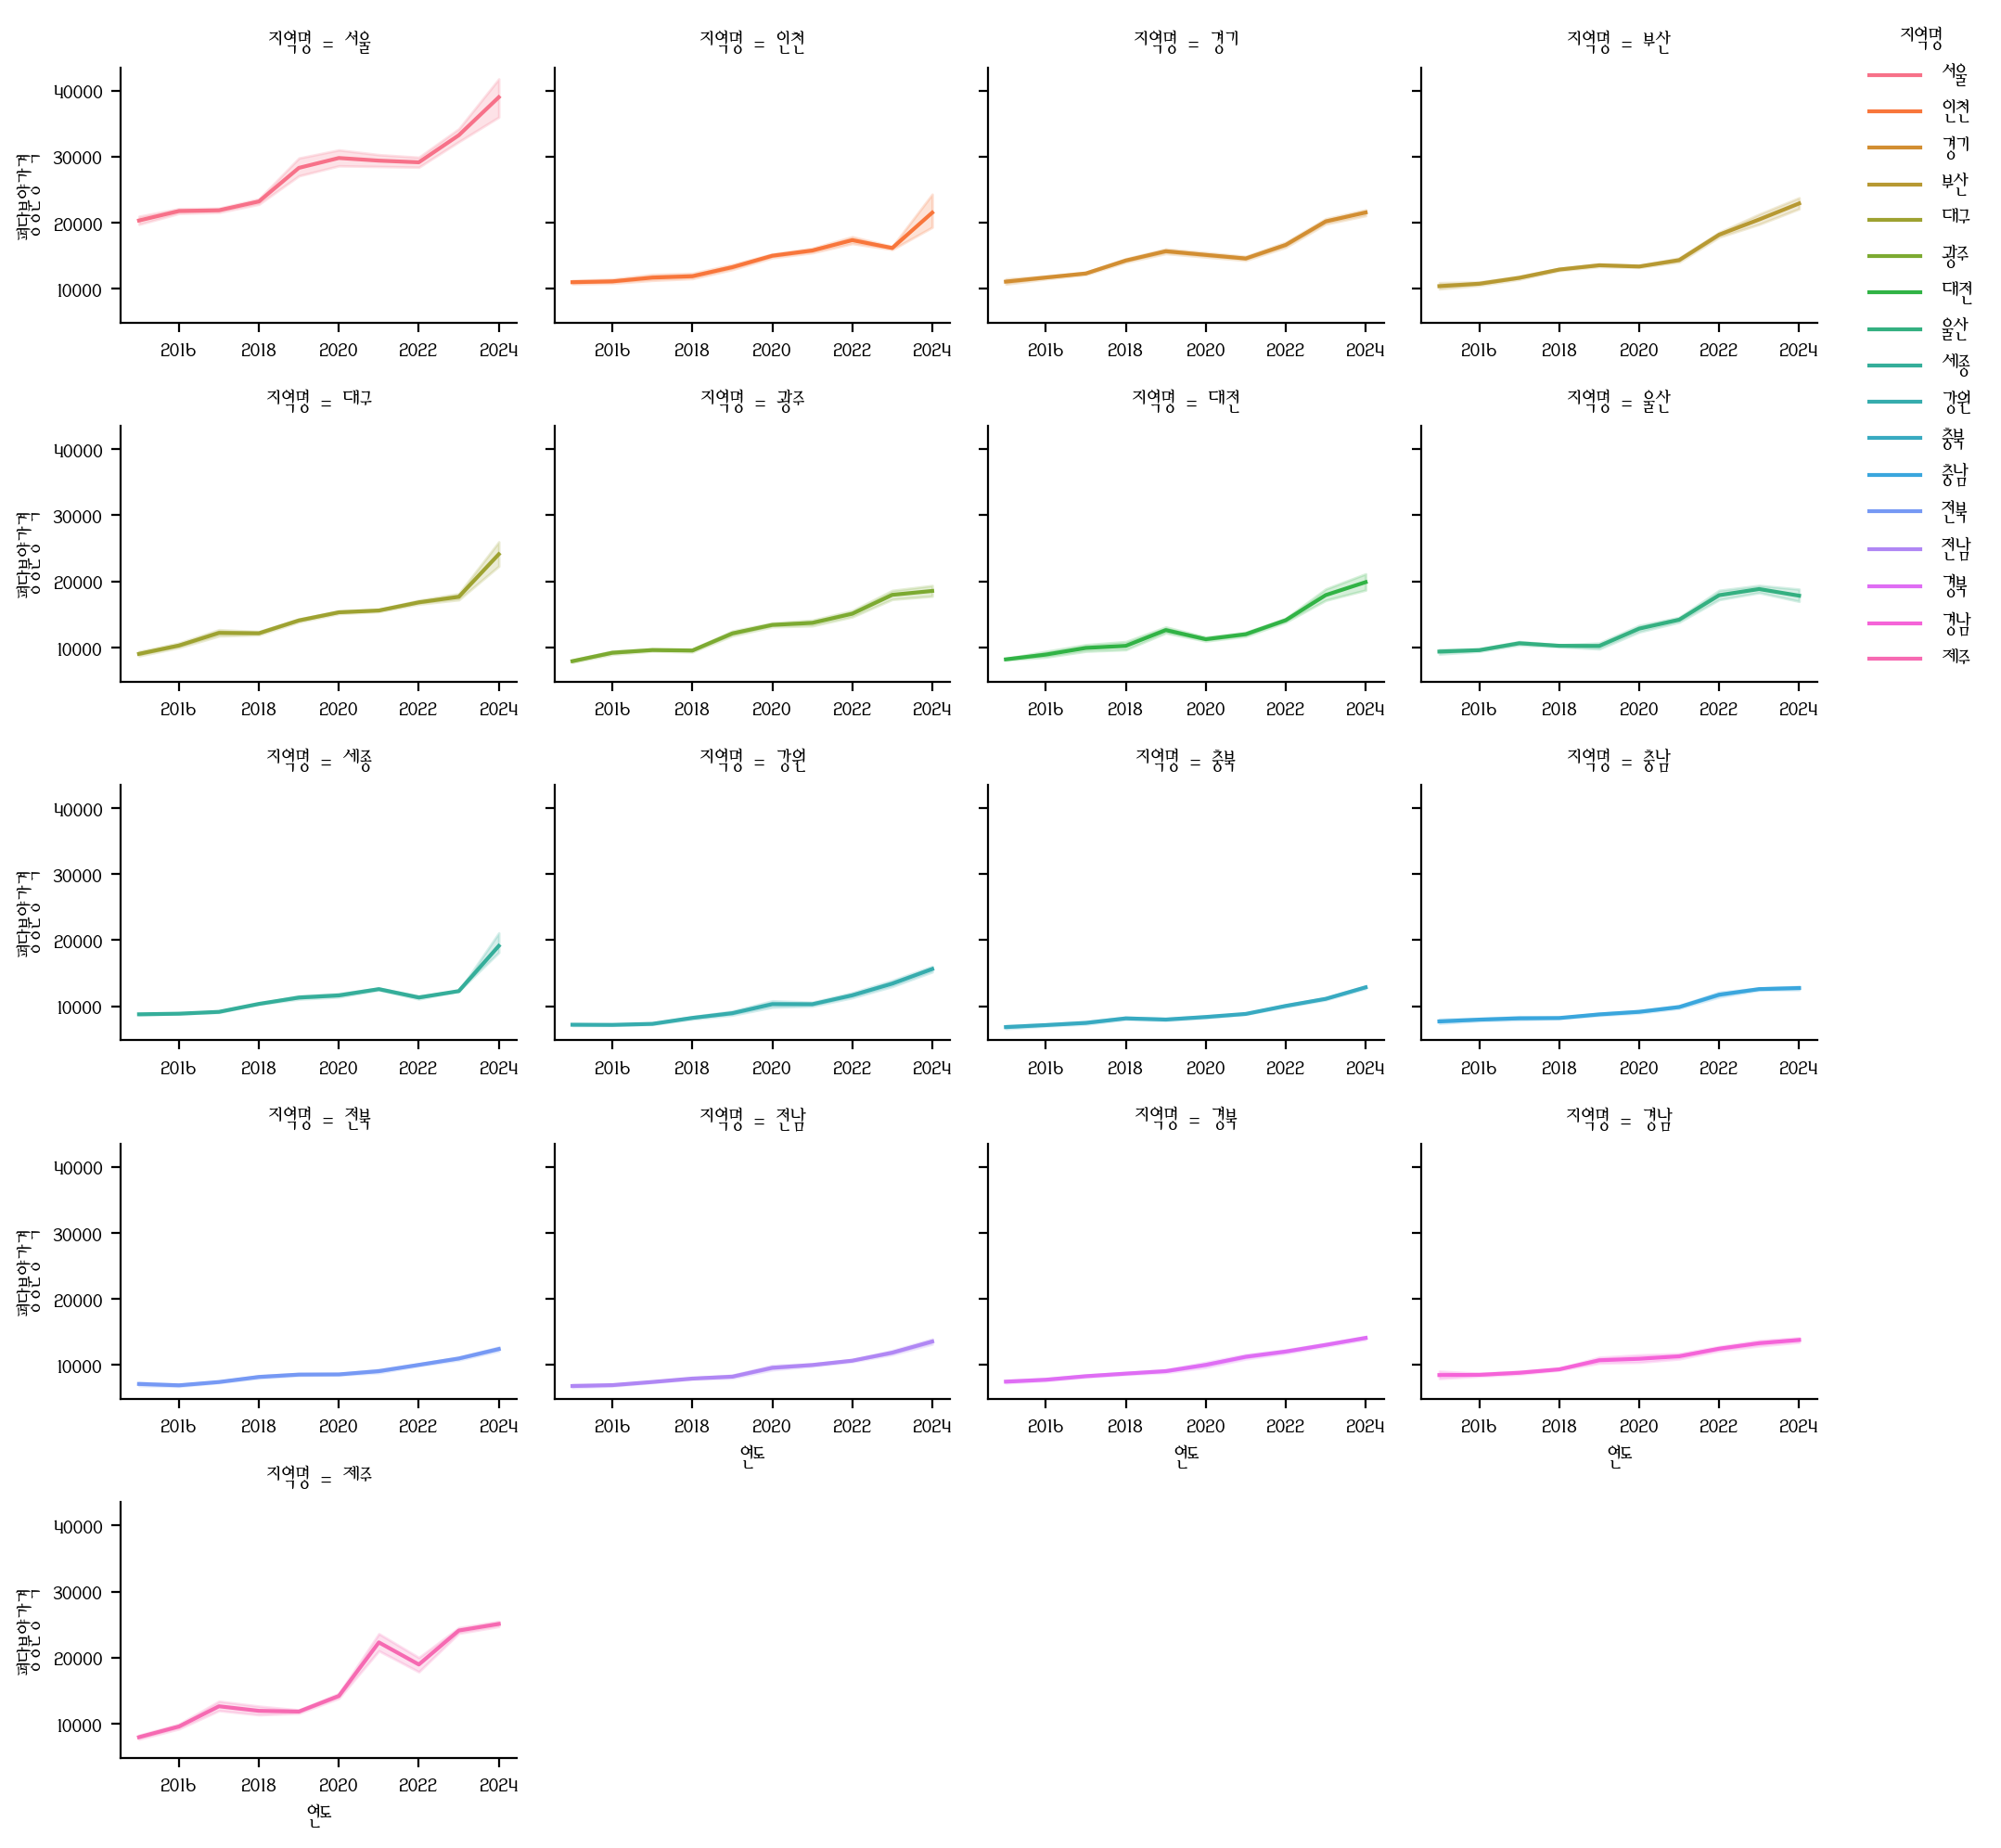

In [373]:
#지역별 평당분양가격의 추이(lineplot)- 지역별 서브플롯
g = sns.relplot(data=df_last, x='연도', y='평당분양가격', hue='지역명', kind='line', col='지역명', col_wrap=3
               )
g.fig.set_size_inches(10,10) #서브플롯 사이즈 조정
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout() #서브플롯 레이아웃 타이트하게 조정

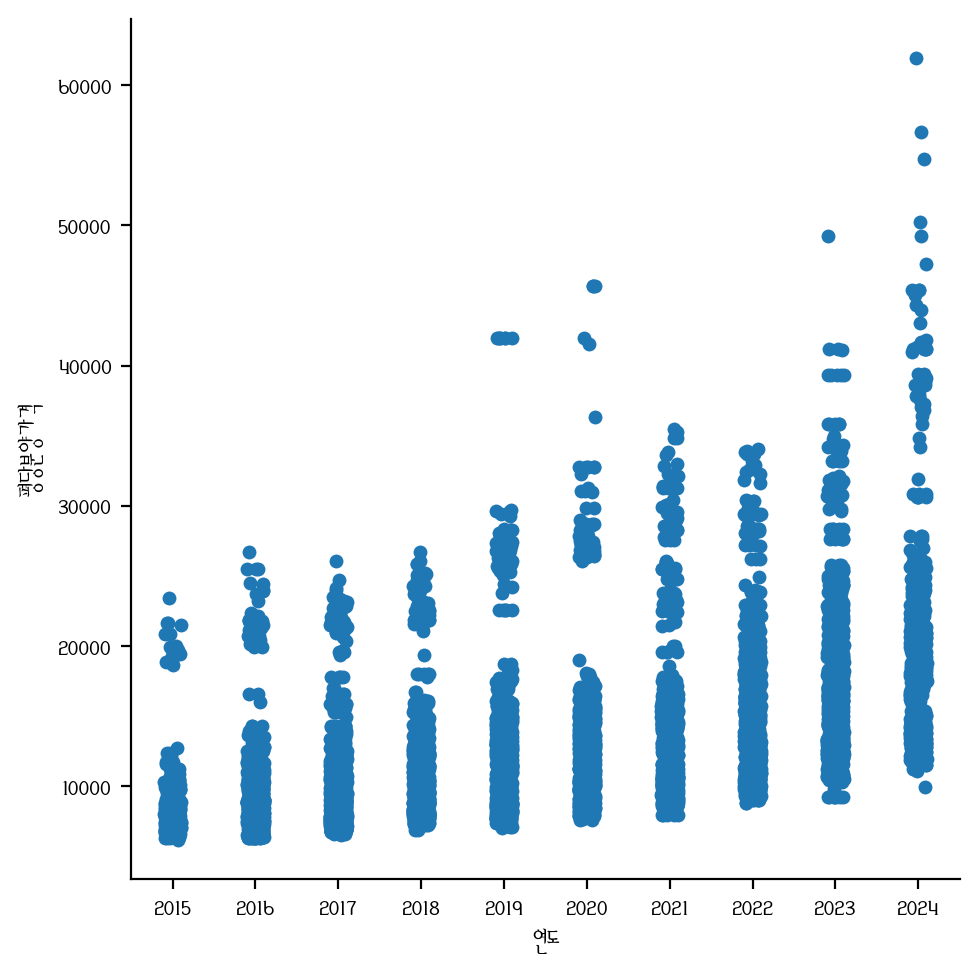

In [381]:
#지역별 평당분양가격의 추이(lineplot)- 지역별 서브플롯
g = sns.catplot(data=df_last, x='연도', y='평당분양가격'
               )

<Axes: xlabel='연도', ylabel='평당분양가격'>

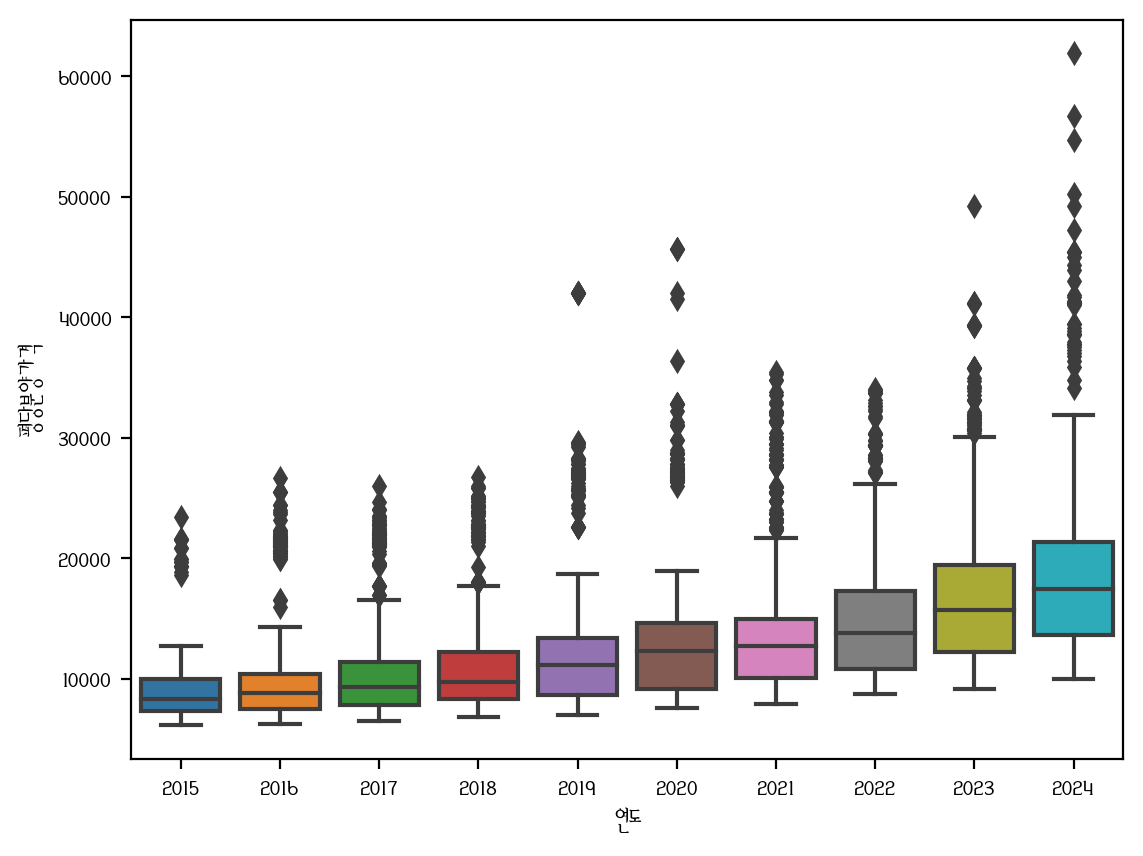

In [375]:
sns.boxplot(data=df_last, x='연도', y='평당분양가격')

<Axes: xlabel='연도', ylabel='평당분양가격'>

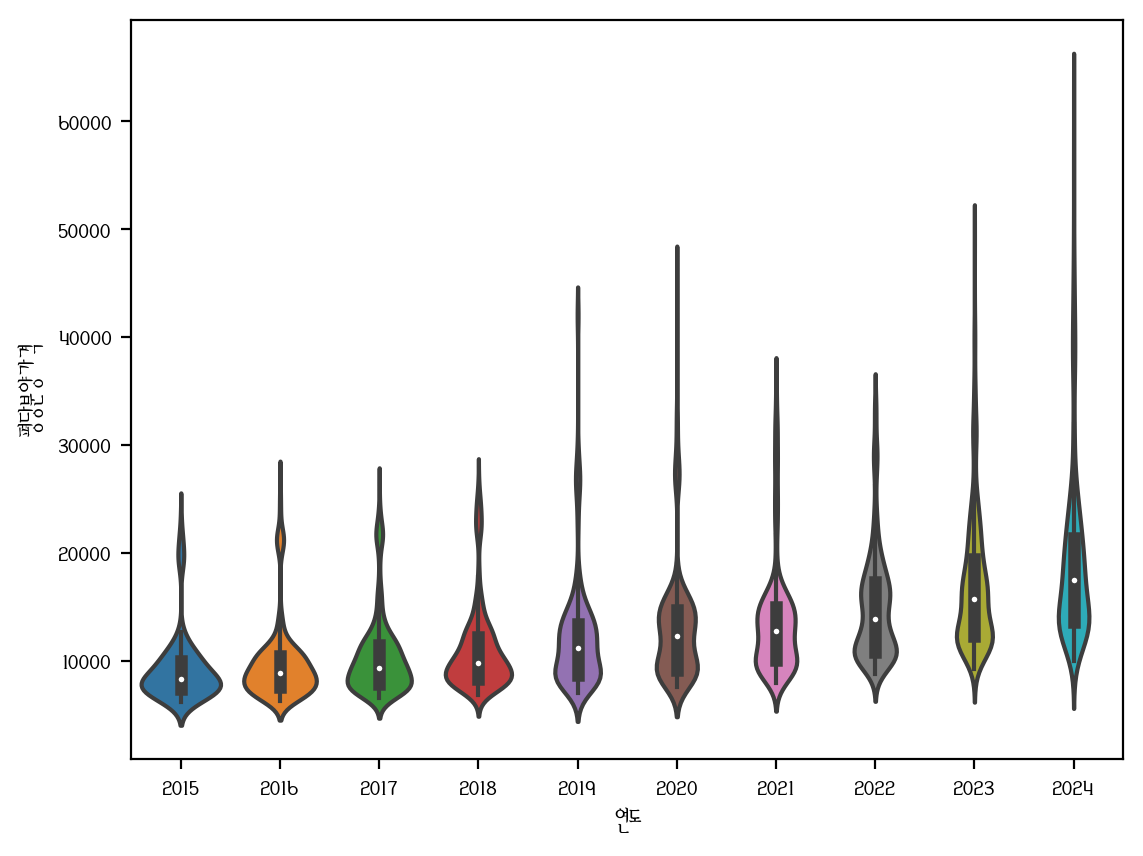

In [380]:
sns.violinplot(data=df_last, x='연도', y='평당분양가격')

<Axes: xlabel='연도', ylabel='평당분양가격'>

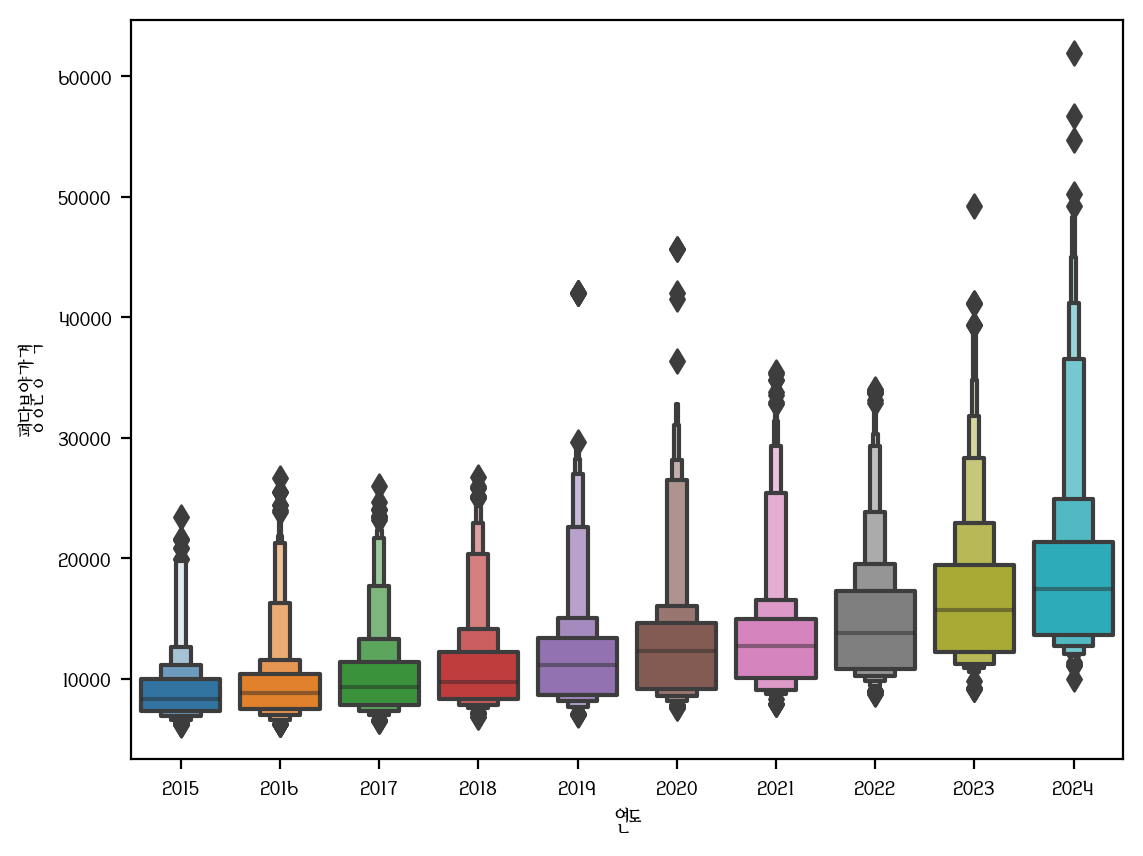

In [382]:
sns.boxenplot(data=df_last, x='연도', y='평당분양가격')

# ==5월 8일 수업전 세팅=

In [39]:
#import패키지
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings(action='ignore') #경고 메세지 무시

#선명도 높임
%config InlineBackend.figure_format = 'retina'

# from IPython.display import set_matplotlib_formats
# set_matplotlib_formats('retina')

sns.set(style='white', rc={'figure.figsize':(15,3)})
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

#데이터
df_last = pd.read_csv('data/df_last.csv')
df_last.sample(1)

,지역명,연도,월,평당분양가격,전용면적
8463,강원,2024,1,17546.1,85~102


In [40]:
df_last.shape #데이터 갯수

(9095, 5)

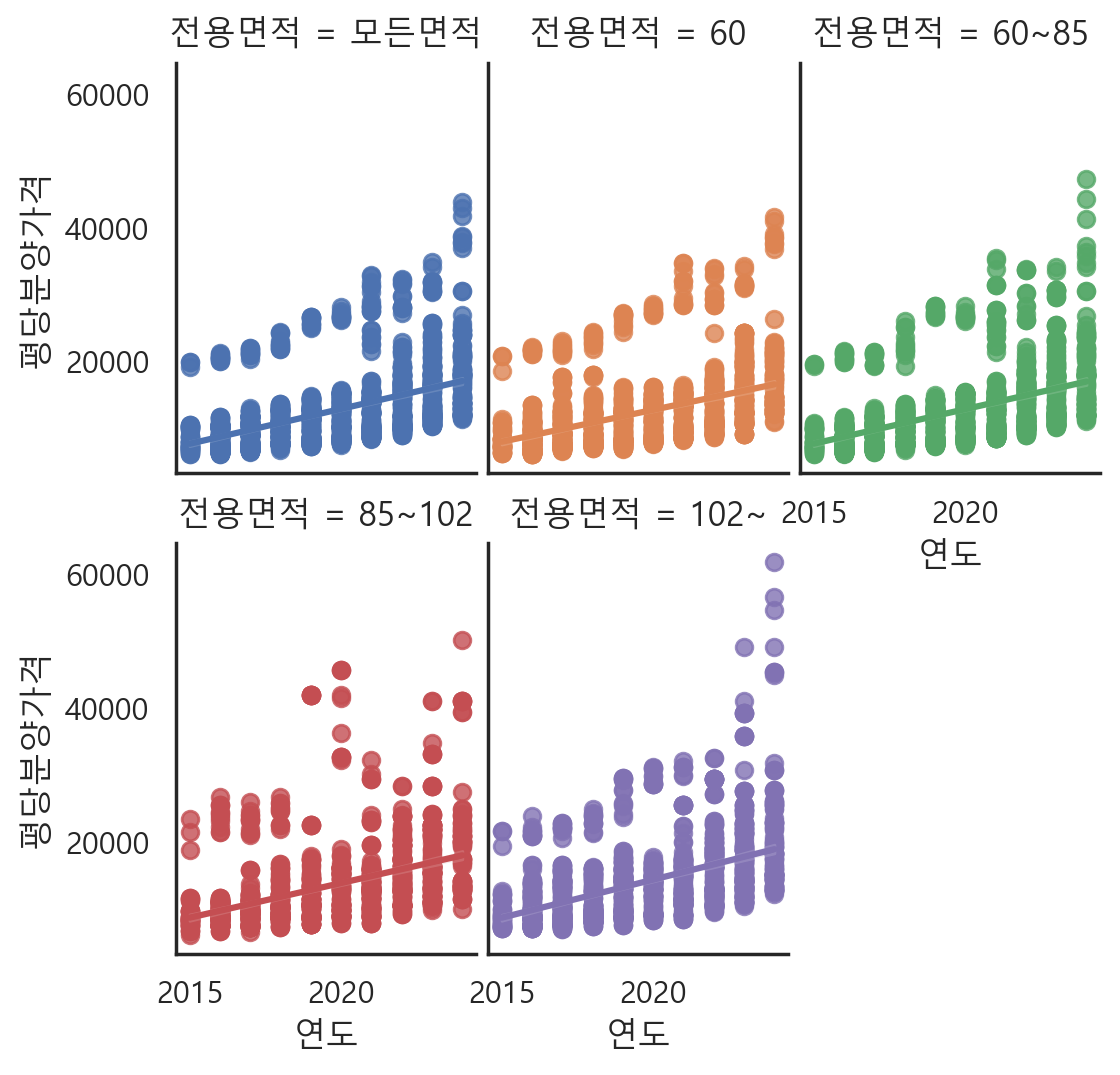

In [41]:
#연도에 따른 평당분양가격을 회귀식으로 시각화(regplot)
g = sns.lmplot(data=df_last, x='연도', y='평당분양가격', hue='전용면적',
          col = '전용면적', col_wrap=3)
g.fig.set_size_inches(5,5)
plt.show()

CPU times: total: 578 ms
Wall time: 584 ms


<Axes: xlabel='연도', ylabel='평당분양가격'>

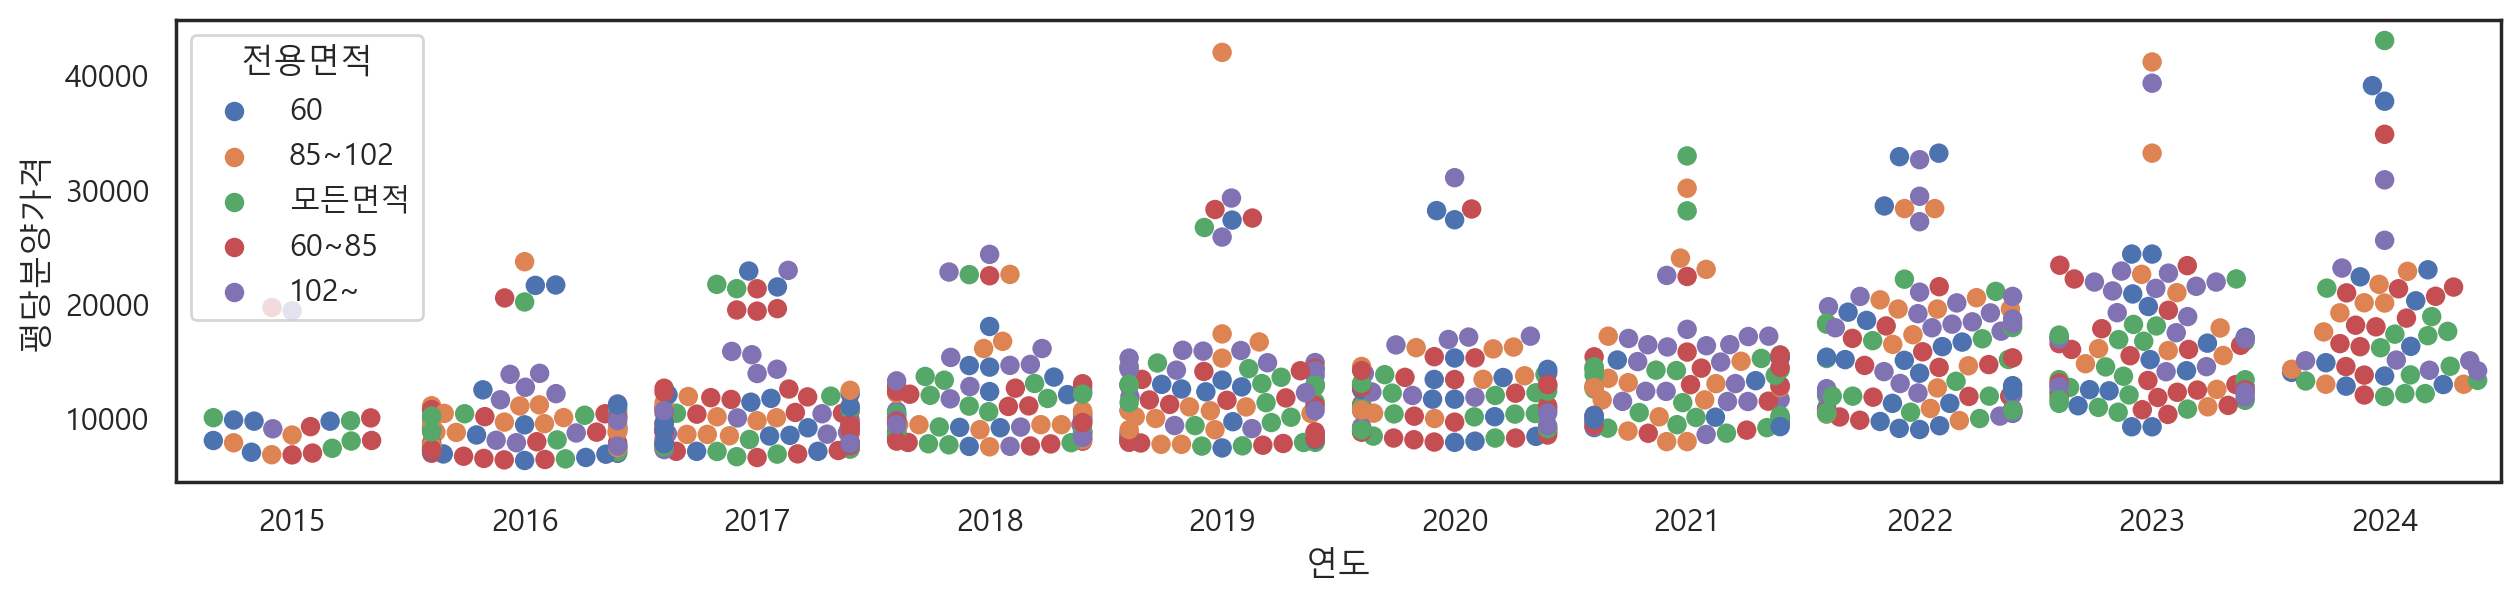

In [42]:
%%time
#분포를 나타내는 swarmplot(많은 데이터-> 샘플링)
df_sample=df_last.sample(frac=0.1, random_state=12)
sns.swarmplot(data=df_sample, x='연도', y='평당분양가격', hue='전용면적', size=7)

In [43]:
#분포를 나타낸ㄴ swramplot(많은 데이터-> 층화샘플링)
from sklearn.model_selection import train_test_split
_, df_sample = train_test_split(df_last, 
                               test_size=0.1,
                               stratify=df_last.연도)

<Axes: xlabel='연도', ylabel='평당분양가격'>

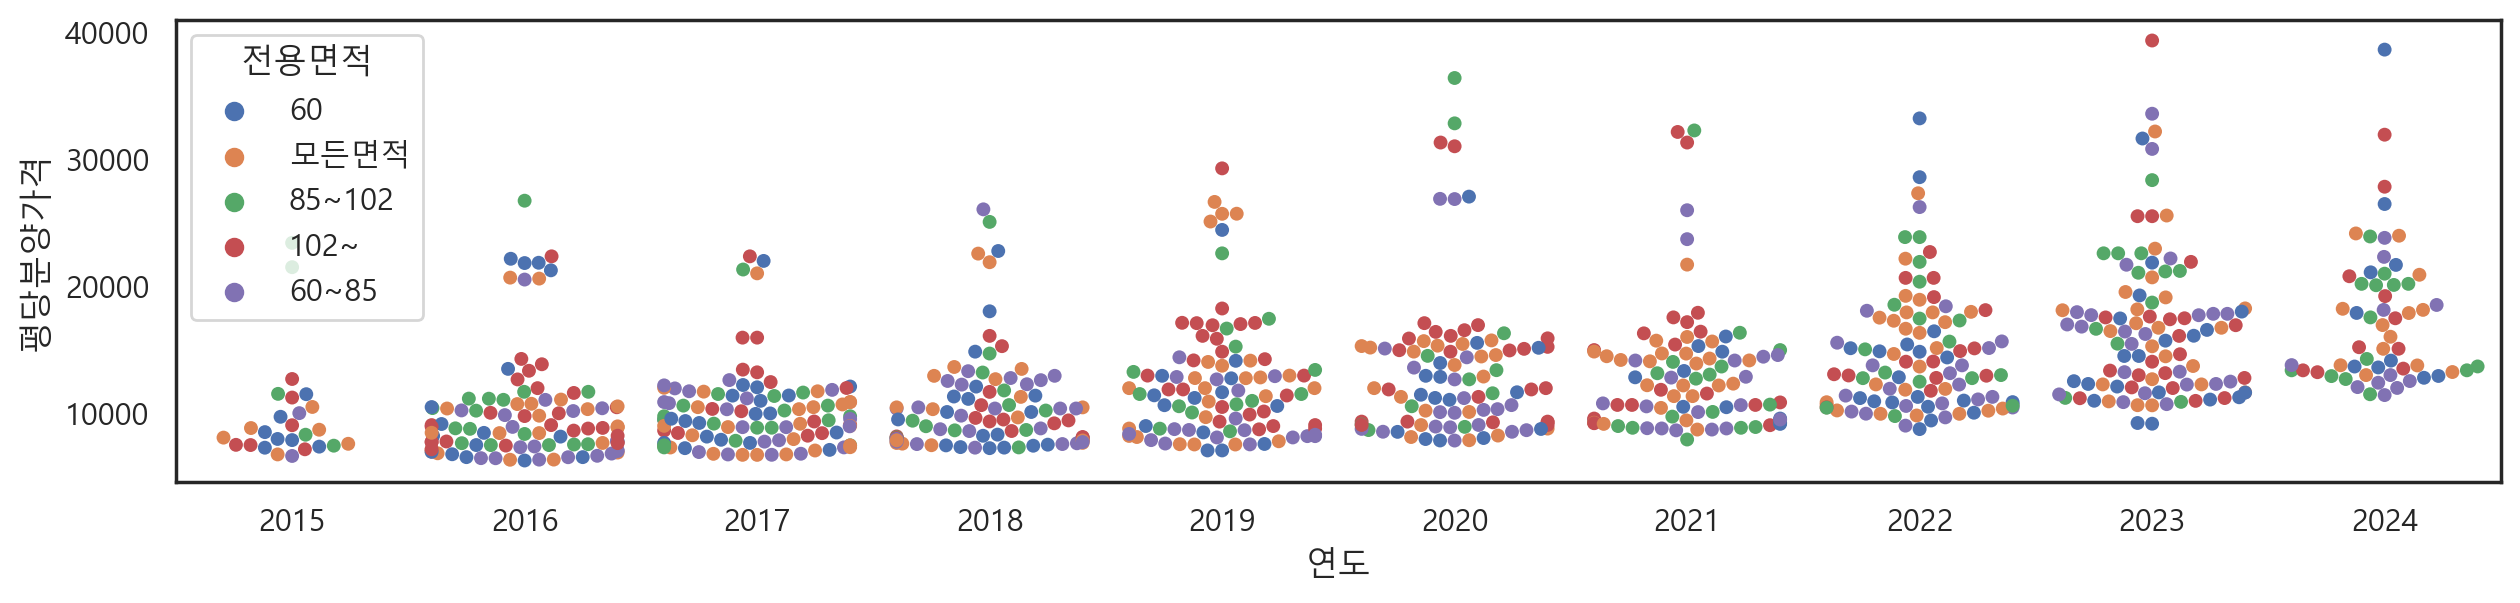

In [44]:
sns.swarmplot(data=df_sample, x='연도', y='평당분양가격', hue='전용면적')

<Axes: >

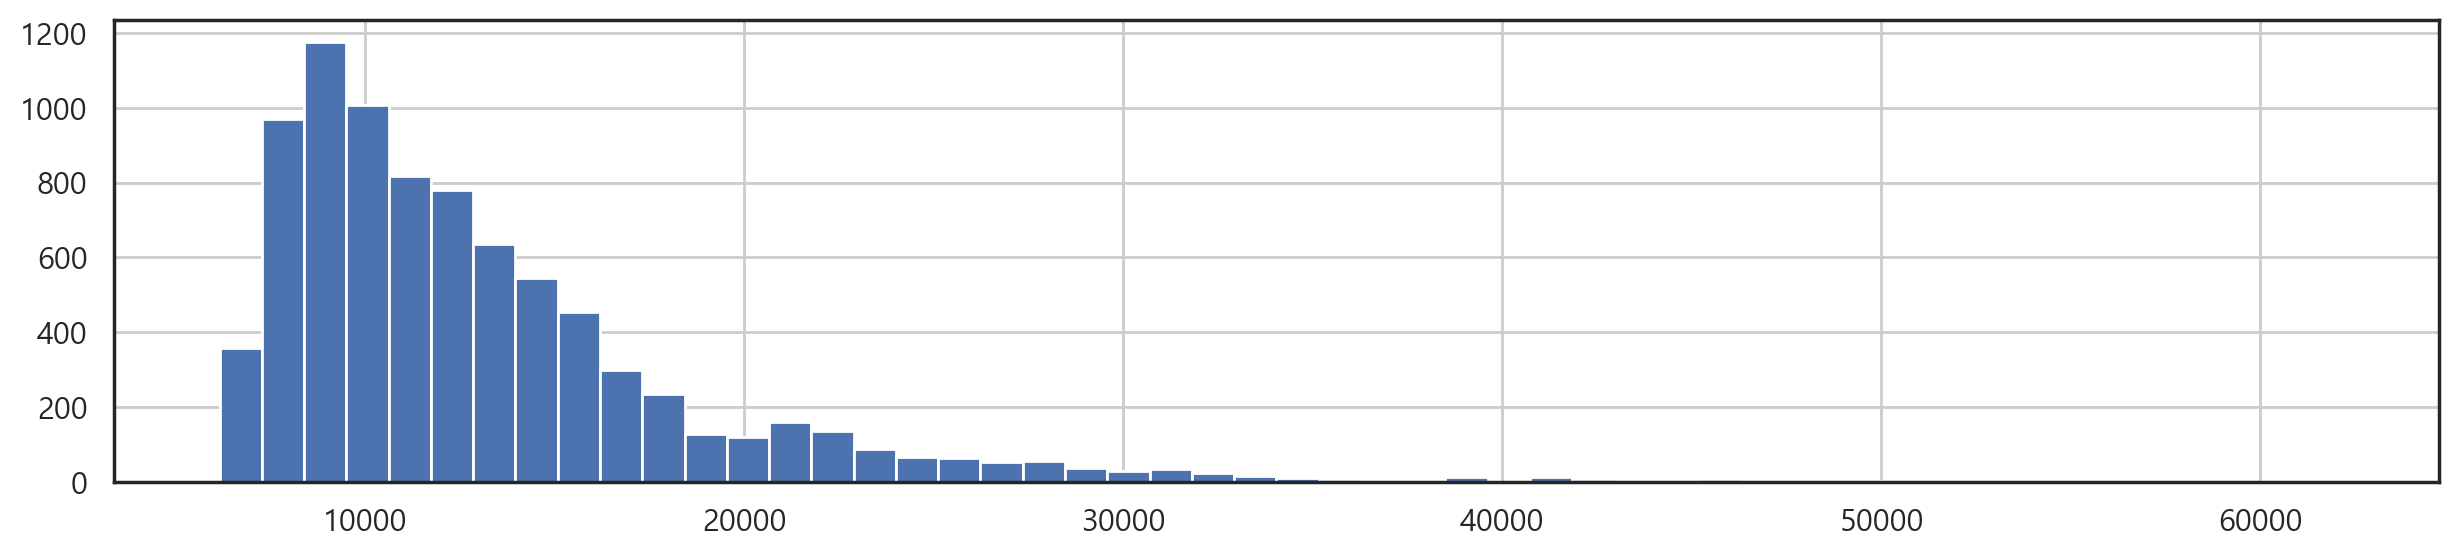

In [45]:
df_last['평당분양가격'].hist(bins=50)

<Axes: xlabel='평당분양가격', ylabel='Count'>

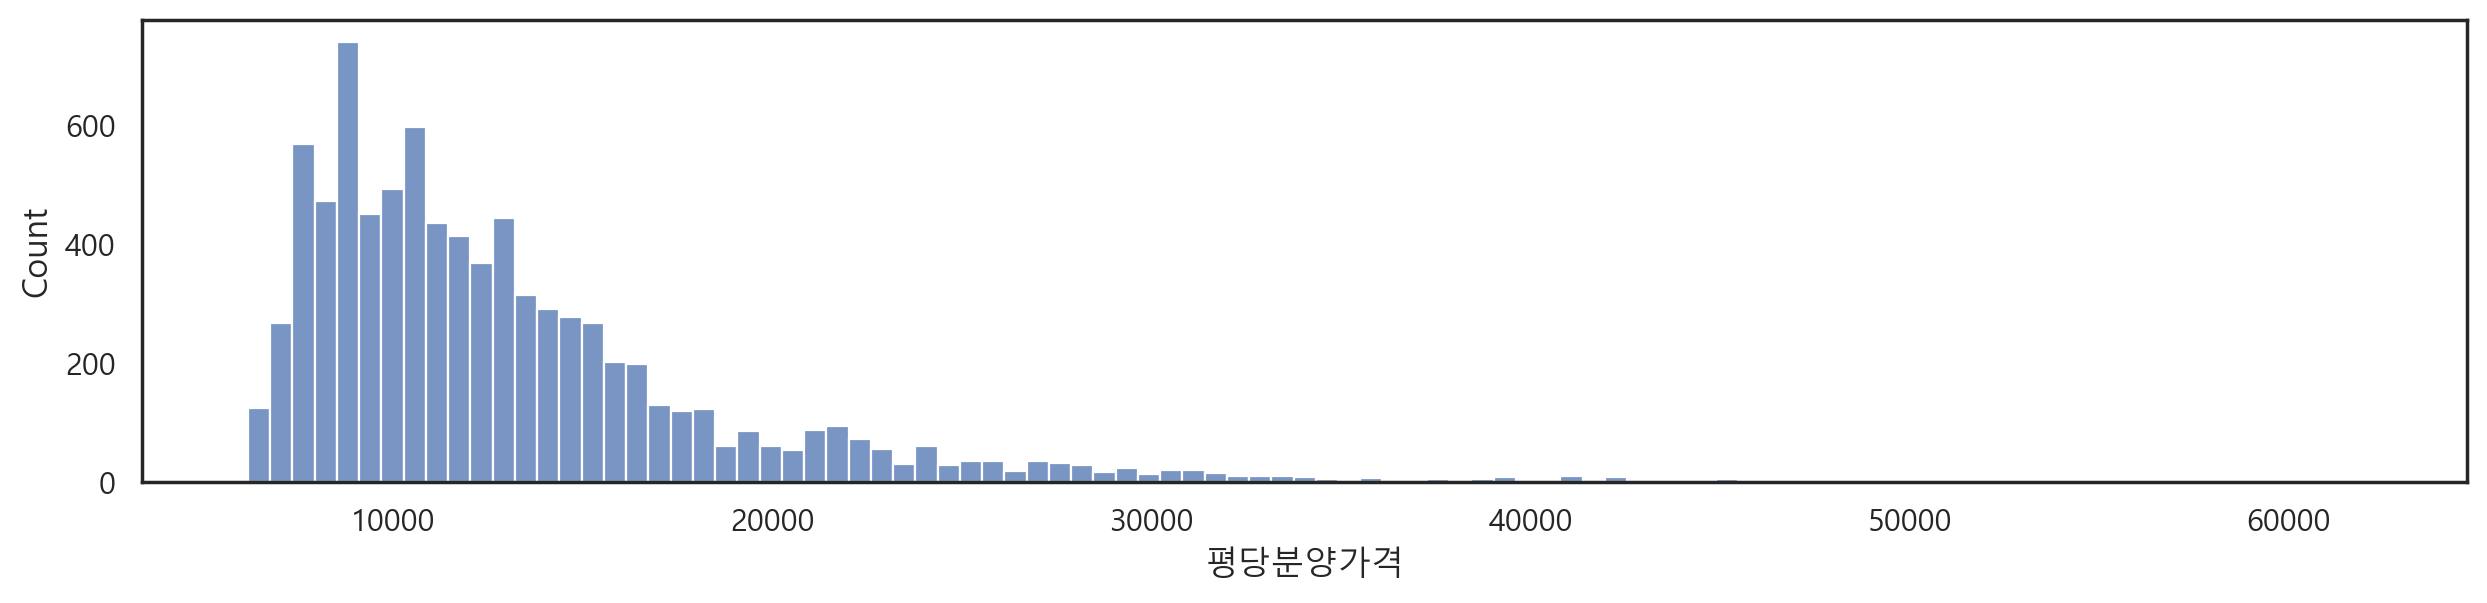

In [46]:
sns.histplot(data=df_last, x='평당분양가격')

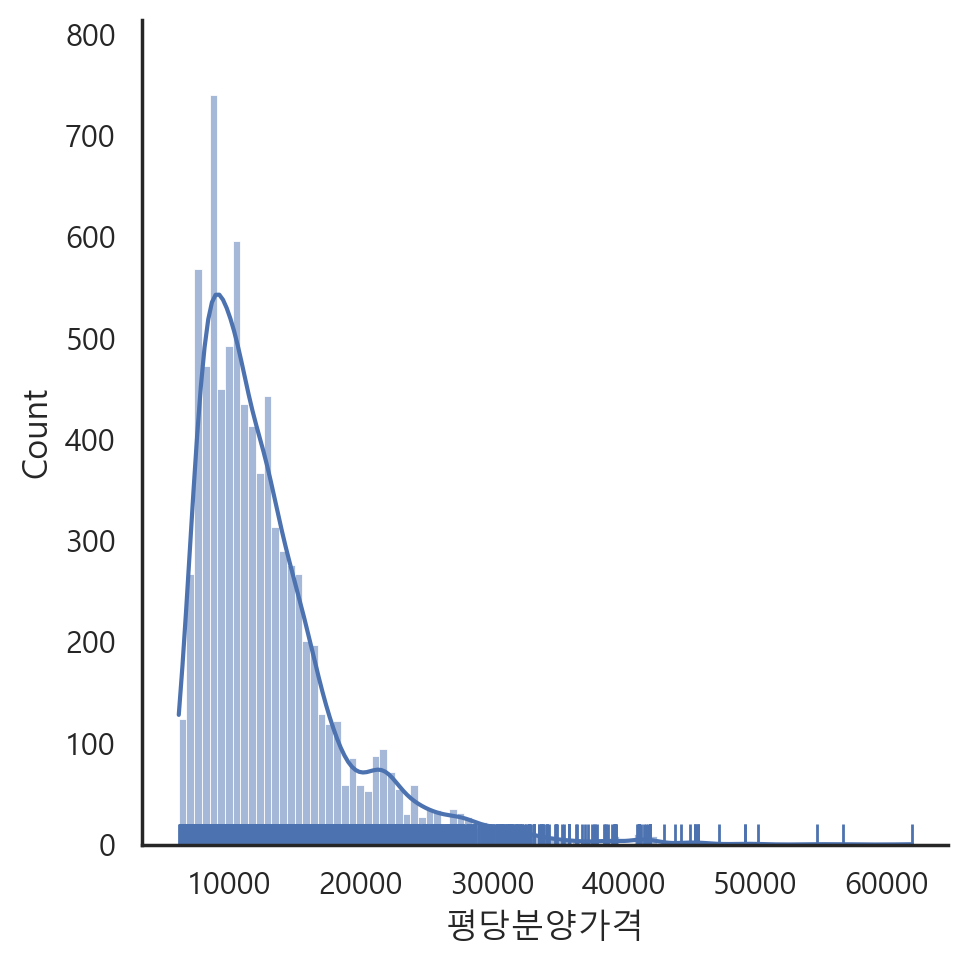

In [47]:
sns.displot(data=df_last, x='평당분양가격', kde=True, rug=True)

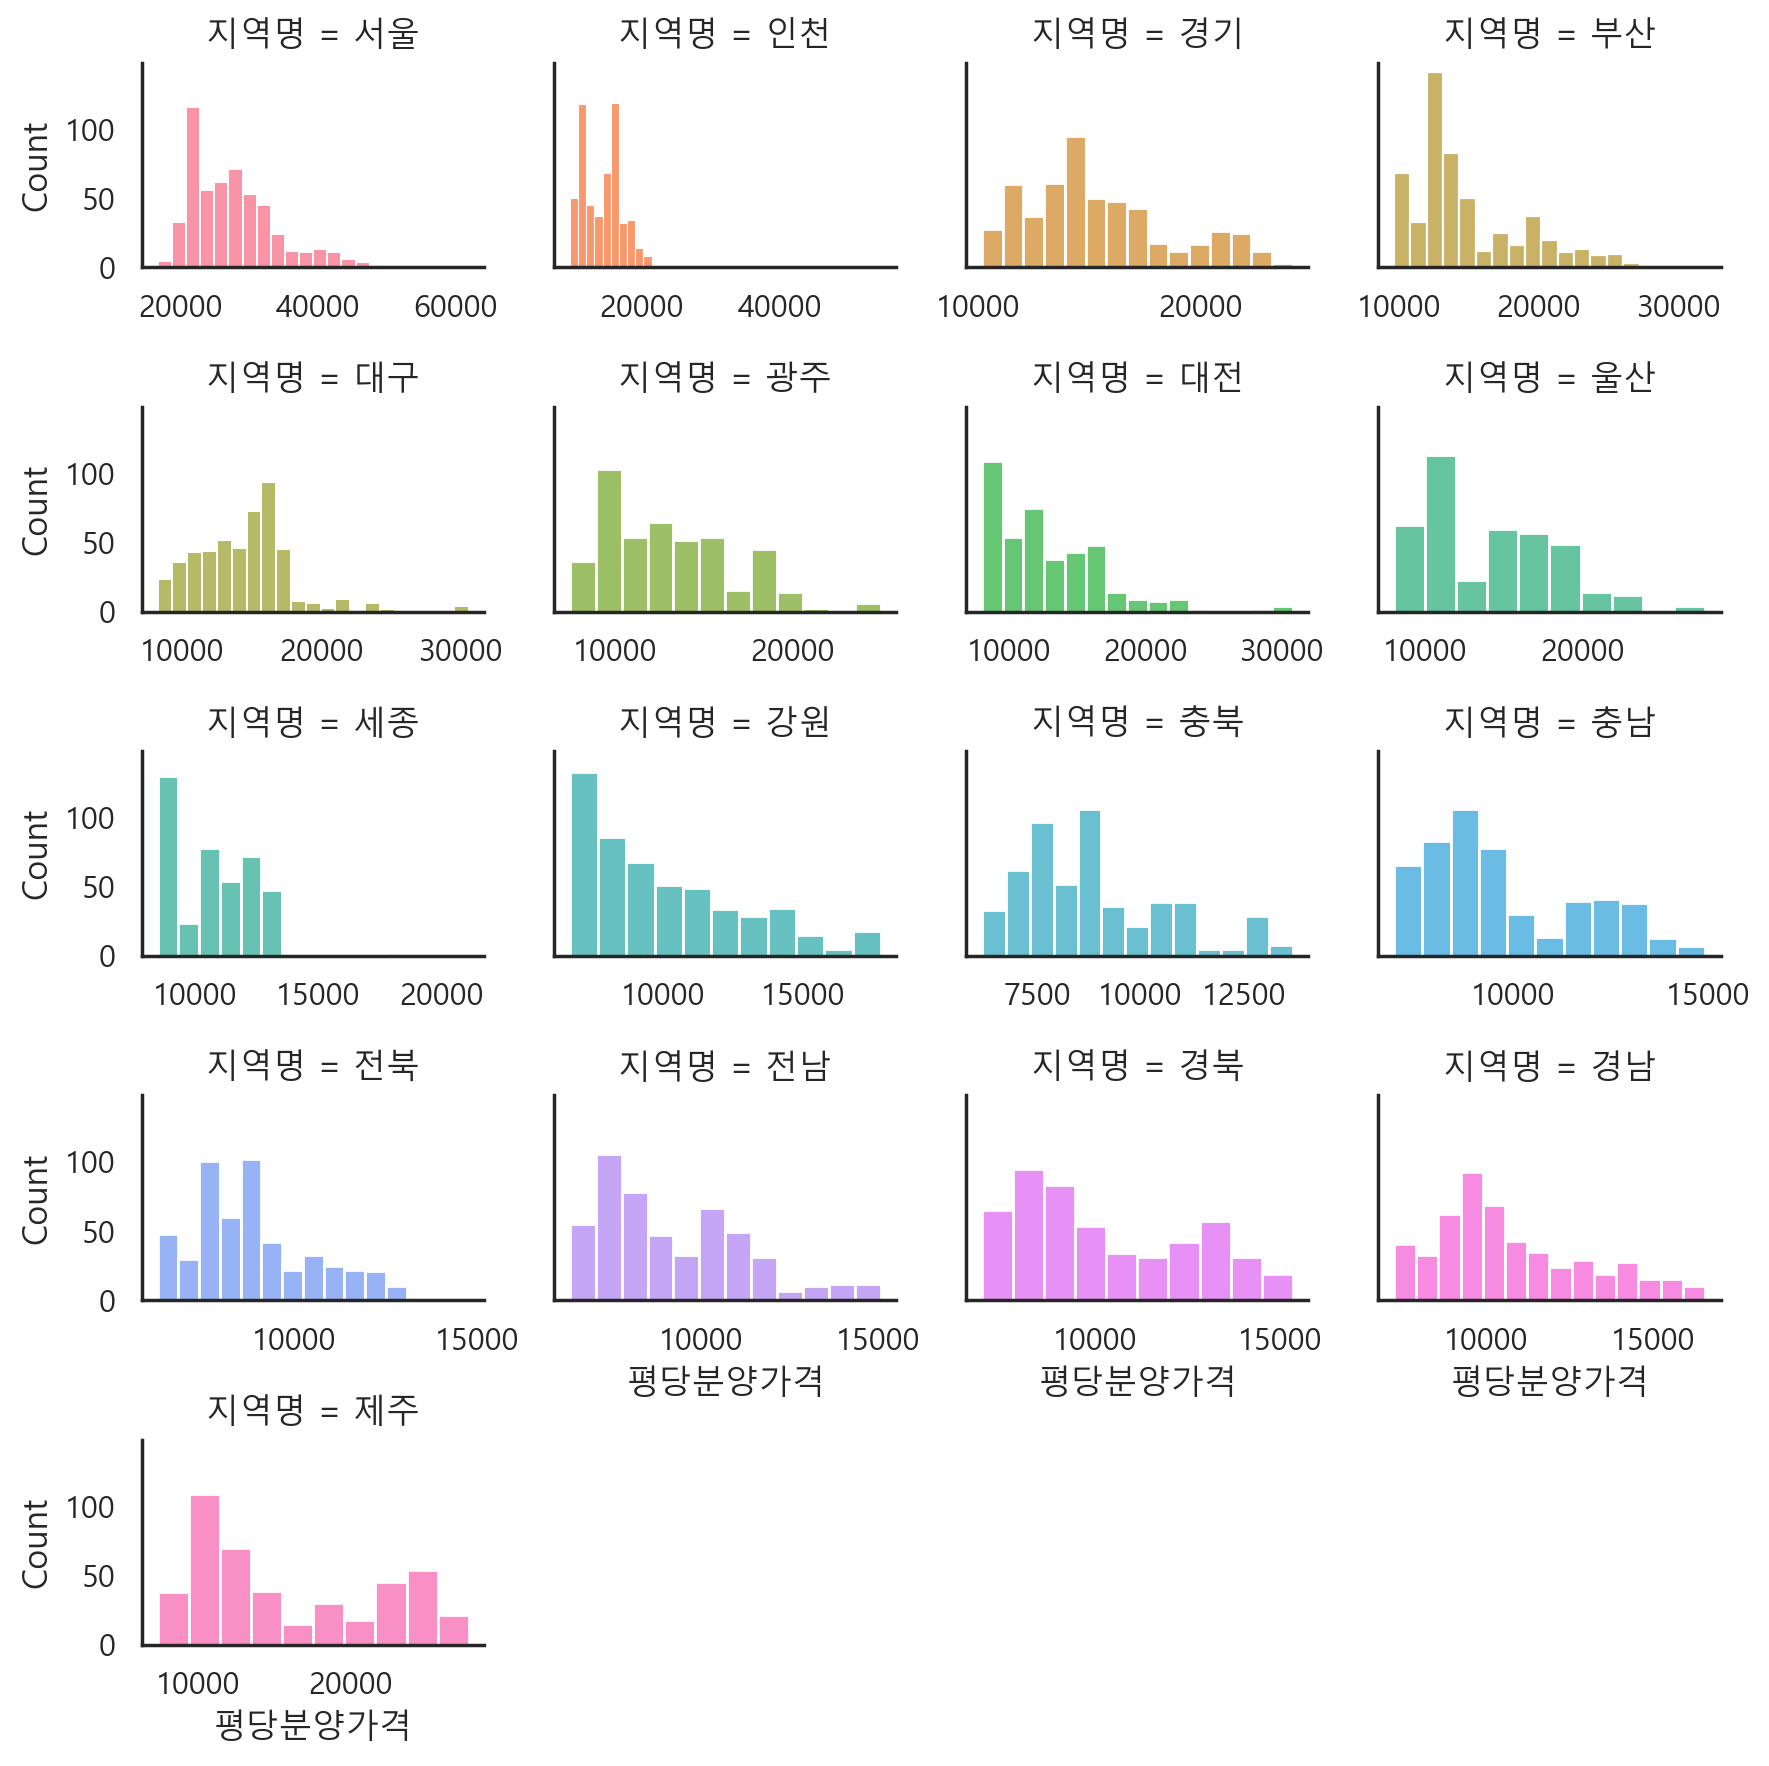

In [48]:
g = sns.FacetGrid(df_last, hue='지역명', col='지역명', col_wrap=4, sharex=False)
g.map(sns.histplot, '평당분양가격')
g.fig.set_size_inches(9,9)#서브플롯 사이즈 조정
plt.tight_layout()#서브플롯 tightg하게 배치
plt.show()

# 10. 구조가 다른 df_first와 df_last를 연결 후 분석
## (1) concat
- new_first :df_first를 [지역명, 연도, 월, 평당분양가격]으로 변환
- new_last : df_last를 [지역명, 연도, 월, 평당분양가격]으로 변환
                (전용면적이 모든면적인 행만 추출후, 전용면적 열을 삭제)

In [50]:
df_first = pd.read_csv('C:/ai_x/download/shareData/부동산/전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv', encoding='cp949')
df_first.sample()

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
11,충남,6365,6365,6379,6287,6552,6591,6644,6805,6914,...,6940,6989,6976,6980,7161,7017,6975,6939,6935,6942


In [51]:
new_first = df_first.melt(id_vars='지역',
             var_name = '연도월',
             value_name='평당분양가격')
new_first.head()

,지역,연도월,평당분양가격
0,서울,2013년12월,18189
1,부산,2013년12월,8111
2,대구,2013년12월,8080
3,인천,2013년12월,10204
4,광주,2013년12월,6098


In [52]:
new_first['연도월'].str.split('년')[0]

['2013', '12월']

In [54]:
#연도 return
def parse_year(data):
    return int(data.split('년')[0])
parse_year('2013년12월')

2013

In [62]:
#월 return
def parse_month(data):
    return int(data.split('년')[1][:-1])
parse_month('2013년12월')

12

In [64]:
new_first['연도'] = new_first['연도월'].map(lambda data : int(data.split('년')[0]))
new_first.head()

,지역,연도월,평당분양가격,연도
0,서울,2013년12월,18189,2013
1,부산,2013년12월,8111,2013
2,대구,2013년12월,8080,2013
3,인천,2013년12월,10204,2013
4,광주,2013년12월,6098,2013


In [65]:
new_first['월']= new_first['연도월'].apply(lambda data : int(data.split('년')[1][:-1]))
new_first.head()

,지역,연도월,평당분양가격,연도,월
0,서울,2013년12월,18189,2013,12
1,부산,2013년12월,8111,2013,12
2,대구,2013년12월,8080,2013,12
3,인천,2013년12월,10204,2013,12
4,광주,2013년12월,6098,2013,12


In [68]:
#연도월 지우기
new_first.drop('연도월', axis=1, inplace=True)

KeyError: "['연도월'] not found in axis"

In [69]:
new_first.head()

,지역,평당분양가격,연도,월
0,서울,18189,2013,12
1,부산,8111,2013,12
2,대구,8080,2013,12
3,인천,10204,2013,12
4,광주,6098,2013,12


In [70]:
new_first.columns = ['지역명', '평당분양가격', '연도', '월']
new_first.tail() #new_first concat(결합)준비 완료

,지역명,평당분양가격,연도,월
352,전북,6580,2015,8
353,전남,6289,2015,8
354,경북,7037,2015,8
355,경남,7665,2015,8
356,제주,7343,2015,8


In [73]:
new_last = df_last[df_last.전용면적=='모든면적'].copy()
new_last.drop('전용면적', axis=1, inplace=True)
new_last

,지역명,연도,월,평당분양가격
0,서울,2015,10,19275.3
5,인천,2015,10,10437.9
10,경기,2015,10,10355.4
15,부산,2015,10,10269.6
20,대구,2015,10,8850.6
...,...,...,...,...
9070,전북,2024,8,12058.2
9075,전남,2024,8,13120.8
9080,경북,2024,8,13827.0
9085,경남,2024,8,13252.8


In [74]:
print(new_first.columns)
print(new_last.columns)

Index(['지역명', '평당분양가격', '연도', '월'], dtype='object')
Index(['지역명', '연도', '월', '평당분양가격'], dtype='object')


In [92]:
df = pd.concat([new_first, new_last], axis=0)
df.index

Int64Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
            ...
            9045, 9050, 9055, 9060, 9065, 9070, 9075, 9080, 9085, 9090],
           dtype='int64', length=2176)

In [93]:
#df의 index reset
#df.index = range(len(df))
df.reset_index(drop=True, inplace=True)

In [80]:
df.index

RangeIndex(start=0, stop=2176, step=1)

In [81]:
df = df[['지역명', '연도', '월', '평당분양가격']]
df.head()

,지역명,연도,월,평당분양가격
0,서울,2013,12,18189.0
1,부산,2013,12,8111.0
2,대구,2013,12,8080.0
3,인천,2013,12,10204.0
4,광주,2013,12,6098.0


## (2) 결측치 대체(연도별, 지역별 중위값)

In [82]:
df.isna().sum()

지역명        0
연도         0
월          0
평당분양가격    26
dtype: int64

In [83]:
df[df['평당분양가격'].isna()]

,지역명,연도,월,평당분양가격
1010,울산,2018,12,NaN
1027,울산,2019,1,NaN
1044,울산,2019,2,NaN
1061,울산,2019,3,NaN
1078,울산,2019,4,NaN
1095,울산,2019,5,NaN
1112,울산,2019,6,NaN
1129,울산,2019,7,NaN
1146,울산,2019,8,NaN
1283,세종,2020,4,NaN


In [ ]:
#연도별 지역별 중앙값으로 결측치 대체 방법1

In [86]:
fillnavalue = df.groupby(['연도', '지역명'])['평당분양가격'].median().unstack()
fillnavalue = df.pivot_table(index='연도', columns='지역명', values='평당분양가격',
                            aggfunc='median')
fillnavalue

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
연도,,,,,,,,,,,,,,,,,
2013,6230.00,10855.00,6473.00,6168.00,6098.00,8080.00,8321.00,8111.00,18189.00,7601.0,8090.00,10204.00,5678.00,6282.00,7674.00,6365.00,6589.00
2014,6350.00,10449.00,6611.50,6555.00,7617.00,8317.00,8327.00,9233.00,19070.50,8067.0,8153.00,10018.00,5716.00,6335.00,7900.00,6724.50,6593.50
2015,6986.00,10518.00,7665.00,7006.00,7914.00,8542.00,8079.00,9515.00,19275.30,8669.0,9192.00,10443.00,6243.00,6583.00,7365.60,6975.00,6705.60
2016,6964.65,11342.10,7865.55,7385.40,8987.55,10335.60,8380.35,10414.80,20654.70,8860.5,10127.70,10531.95,6491.10,6369.00,9329.10,7377.15,6801.30
2017,7057.05,11919.60,8052.00,7835.85,9551.85,11231.55,9035.40,11851.95,21402.15,9018.9,11488.95,10875.15,7114.80,7222.05,10885.05,7448.10,6765.00
2018,7669.20,13099.35,8898.45,8667.45,9678.90,12178.65,9807.60,12926.10,22567.05,10388.4,10312.50,11233.20,7774.80,7652.70,11649.00,8030.55,7870.50
2019,8221.95,14487.00,9791.10,8723.55,12071.40,13963.95,11866.80,13061.40,26428.05,11411.4,10362.00,12827.10,7920.00,8146.05,12561.45,8598.15,7570.20
2020,9271.35,14331.90,10263.00,9929.70,12624.15,15302.10,11030.25,13266.00,26769.60,11355.3,12581.25,14648.70,8571.75,8225.25,15130.50,8863.80,7924.95
2021,9607.95,14173.50,10523.70,10338.90,14127.30,15528.15,12196.80,14460.60,29769.30,12533.4,14256.00,14950.65,9857.10,8834.10,23756.70,9306.00,8677.35


In [89]:
def fillna_median(row):
    'row.평당분양가격이 결측치면 fillnavalue[row.연도, row.지역명]으로 대체한다'
    year = row.연도
    loc = row['지역명']
    if np.isnan(row.평당분양가격):
        row['평당분양가격'] = fillnavalue.loc[year,loc]
    return row

fillna_median(df.loc[1010])

지역명            울산
연도           2018
월              12
평당분양가격    10312.5
Name: 1010, dtype: object

In [95]:
df1 = df.apply(fillna_median, axis=1)
df1

,지역명,평당분양가격,연도,월
0,서울,18189.0,2013,12
1,부산,8111.0,2013,12
2,대구,8080.0,2013,12
3,인천,10204.0,2013,12
4,광주,6098.0,2013,12
...,...,...,...,...
2171,전북,12058.2,2024,8
2172,전남,13120.8,2024,8
2173,경북,13827.0,2024,8
2174,경남,13252.8,2024,8


In [91]:
df.apply(fillna_median, axis=1).isna().sum()

지역명       0
연도        0
월         0
평당분양가격    0
dtype: int64

In [99]:
#연도별 지역별 중앙값으로 결측치 대체 방법2
df2 = df.copy()
df2['평당분양가격'] = df2.groupby(['지역명', '연도'])['평당분양가격'].transform(lambda x : x.fillna(x.median()))

In [100]:
df2.isnull().sum()

지역명       0
평당분양가격    0
연도        0
월         0
dtype: int64

In [101]:
df2

,지역명,평당분양가격,연도,월
0,서울,18189.0,2013,12
1,부산,8111.0,2013,12
2,대구,8080.0,2013,12
3,인천,10204.0,2013,12
4,광주,6098.0,2013,12
...,...,...,...,...
2171,전북,12058.2,2024,8
2172,전남,13120.8,2024,8
2173,경북,13827.0,2024,8
2174,경남,13252.8,2024,8


## (3) df.csv파일로 출력

In [102]:
df1.to_csv('C:/ai_x/download/shareData/부동산/최종전국평당분양가격(concat결측치제외).csv', index=False, encoding='cp949')

In [103]:
df = pd.read_csv('C:/ai_x/download/shareData/부동산/최종전국평당분양가격(concat결측치제외).csv', encoding='cp949')

## (4) 7절부터 9절까지 분석을 한다(전용면적별 분석은 불가)

- 지역명별 데이터 갯수는 결측치가 없어서 동일(groupby나 pivot_table등으로 확인)
- 지역명별 평당분양가격(groupby, pivot_table, plot, seaborn 연습)
- 연도별 지역명별 평당분양가격(groupby, pivot_table, plot, seaborn 연습)

### ① 지역명별 데이터 행 갯수 : 결과가 1차원 시리즈

In [104]:
df['지역명'].value_counts()

서울    128
강원    128
경남    128
경북    128
전남    128
전북    128
충남    128
충북    128
세종    128
부산    128
경기    128
울산    128
대전    128
광주    128
인천    128
대구    128
제주    128
Name: 지역명, dtype: int64

### ② 지역별 평당분양가격(평균, 최대값, ... 요약통계량)

In [106]:
df.groupby('지역명')['평당분양가격'].max().sort_values()

지역명
전북    12487.2
충남    12823.8
충북    13011.9
전남    13401.3
경북    13827.0
경남    14543.1
강원    15120.6
세종    18126.9
대전    18767.1
울산    18932.1
경기    21591.9
광주    23964.6
부산    27017.1
제주    27574.8
대구    30600.9
인천    41830.8
서울    43939.5
Name: 평당분양가격, dtype: float64

In [ ]:
# 지역명당 평당분양가격 시각화(lineplot과 matplotlib의 bar, sns의 barplot)

### ③ 연도별 평당분양가격(평균)

In [ ]:
# 연도별 평당분양가격 시각화(lineplot과 matplotlib의 bar, sns의 barplot)

### ④ 연도, 지역별 평당분양가격(평균)

In [ ]:
# 연도별, 지역별 평당분양가격 시각화(heatmap)

In [ ]:
# 년도별 평균 평당분양가격의 추이

In [ ]:
# 위의 그래프가 겹쳐서 작 보이지 않아 분리

In [ ]:
# 관계형 그래프의 서브플롯을 그리는 함수는 relplot
# 범주형 그래프의 서브플롯을 그리는 함수는 catplot

In [ ]:
# 연도별 평당분양가격의 사분위수


In [ ]:
# 연도별 평당분양가격의 사분위수(분포포함 boxenplot)


In [ ]:
# 연도별 평당분양가격의 사분위수(분포포함 violinplot)


In [ ]:
# 연도에 따른 평당분양가격을 회귀식으로 시각화


In [ ]:
# swarmplot은 많은 데이터를 그리기에는 시간이 많이 걸려 5%만 sampling후 그릴 것을 추천
# 연도별 평당분양가격 산점도
 

In [ ]:
# 분양가격을 hist
